##Veritas Submission

##Instructors: Prof. Dr. Ramesh Karri, Weihua Xiao
##Student: Tejas Attarde

<h1>Veritas</h1>
<h4>Works like ChipChat, AutoChip, Verigen and others have shown that LLMs can be used for verilog code generation. But it is often seen that the code generated by the LLM end up having issues like syntax errors and incorrect logic. To analyse the correctness of the code an expert's supervision is often required. Exhaustive test-cases are written to verify and test the logic. In veritas we integrate the verification and testing phase with the generation phase itself. We leverage the power of LLMs to understand initial simple contexts and generate complex outputs based on that. Each circuit is a combination of some logics like AND, NAND, NOR, XNOR etc. Each of these logics have an equivalent Conjunctive Normal Form (CNF) representation (refer figure below). A full circuit can be represented as the conjunction of CNF clauses representing the individual logic gates in the circuit. Our Veritas framework starts with CNF generation for simple circuits and used the generated result as future context to generate bigger and more complex circuits.</h4>



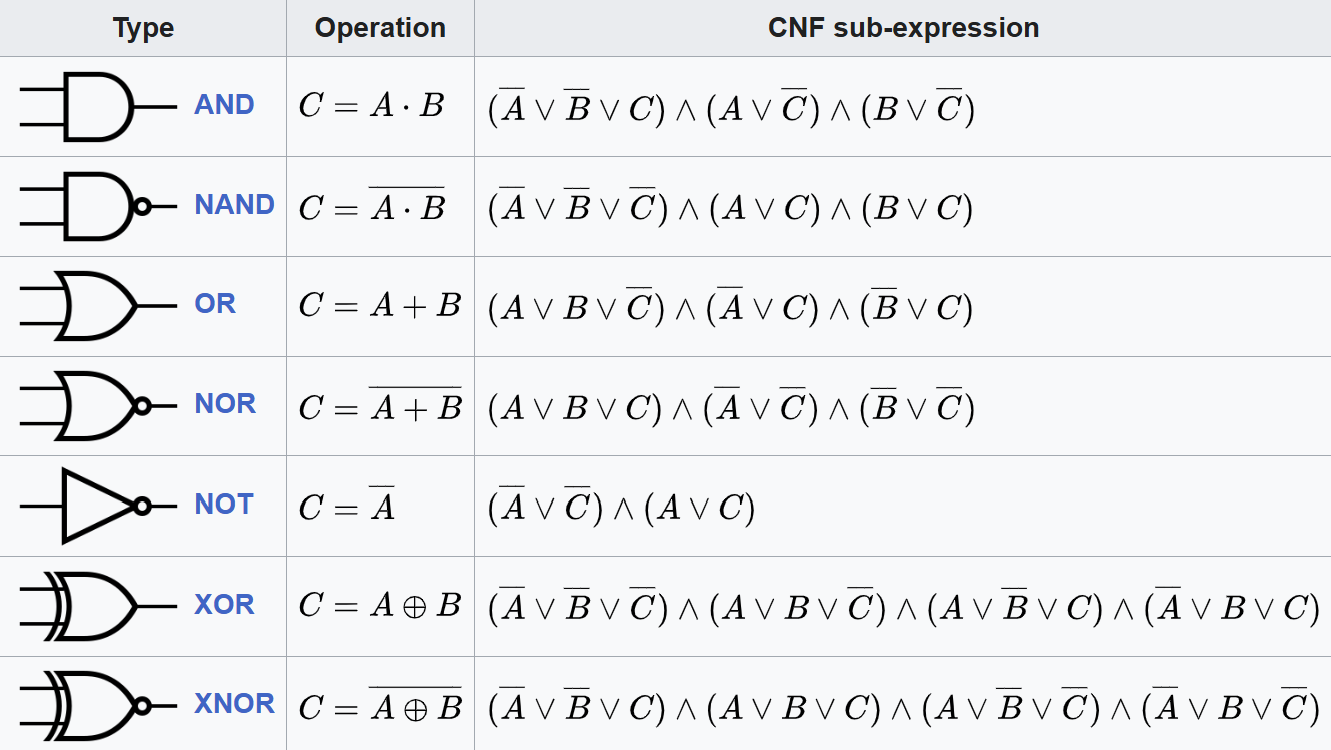

<h4>Veritas generates correct CNF equations for various designs like adder, subtractor, multiplexer, multiplicator, decoder.
Veritas leverages the idea that correct CNF can always be converted to correct verilog code that does not require further testing.</h4>
    Design Name :  Possible configuration

    "adder":       ["1-bit", "2-bit", "3-bit", "4-bit", "5-bit"]
    "subtractor":  ["1-bit", "2-bit", "3-bit", "4-bit", "5-bit"]
    "multiplier":  ["1-bit", "2-bit", "3-bit"]
    "decoder":     ["1x2", "2x4", "3x8", "4x16", "5x32"]
    "multiplexer": ["2x1", "4x1", "8x1", "16x1", "32x1"]


In [ ]:
API_KEY = " "


###Part I — Run 1: 3-bit Adder

Design: adder

Type: 3-bit

Inputs: A0, B0, A1, B1, A2, B2, Cin (7 primary inputs)

Outputs: S0, S1, S2, Cout (3 sum bits + carry-out)

Intermediate signals: C1, C2 (internal carries between stages)

This run executes the full Veritas pipeline (Steps 2–5) for a 3-bit ripple-carry adder.

The LLM incrementally builds the CNF: first for a 1-bit full adder, then extends to 2-bit, then to 3-bit.

In [ ]:
DESIGN = "adder"
TYP = "3-bit"

<h4>This part of the code enquires gpt-5-mini model incrementally to get the correct CNF equation for a design. This might take a couple of minutes due to multiple communication with the LLM. the idea is to first obtain the cnf for the smallest version of the design. Then asking the LLM to use it as reference to come up with bigger and more complex designs.</h4>

In [ ]:
from __future__ import annotations
import argparse
import os
import re
import sys
from typing import Dict, List
from openai import OpenAI
import logging
#import os
import time

# -----------------------------
# Dispatch stubs (plug your logic here)
# -----------------------------
def run_adder(typ, client) :
    # bit_str like "1-bit", "2-bit", ...
    print(f"[adder] type={typ}")
    # TODO: implement CNF/Verilog/etc.
    # print(generate_adder_cnf(bitwidth))
    reply = ""
    if typ == "1-bit" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",


        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Cout "}
        ]


        )

        last_reply = response.choices[0].message.content
        reply = last_reply


    elif typ == "2-bit" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",

        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Cout "}
        ]


        )

        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit adder, construct a 2-bit adder. The equation of 1-bit adder is :"+last_reply+". Just return the CNF equations."}
        ]
        )
        last_reply_2 = response.choices[0].message.content
        reply = last_reply_2
    else :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",

        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a "+typ+" full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Cout "}
        ]


        )

        last_reply = response.choices[0].message.content
        print(last_reply)
        print("=================================")

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit adder, construct a 2-bit adder. The equation of 1-bit adder is :"+last_reply+". Just return the CNF equations as <output> = <CNF equation>."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)
        print("=================================")

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit adder: "+last_reply+" and the equation of a 2-bit adder: "+last_reply_2+". Construct a "+typ+" adder. Just return the CNF equations  as <output> = <CNF equation>."}
        ]
        )

        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        print("=================================")
        reply = last_reply_3
    return reply


def run_subtractor(typ, client) :
    print(f"[subtractor] type={typ}")

    reply = ""
    if typ == "1-bit" :

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a "+typ+" full subtractor. Assume inputs A, B, Din and outputs S (difference) and Dout (borrow-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Dout "}
        ]
        )

        last_reply = response.choices[0].message.content
        print(last_reply)
        reply = last_reply


    elif typ == "2-bit" :

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full subtractor. Assume inputs A, B, Din and outputs S (difference) and Dout (borrow-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Dout "}
        ]
        )

        last_reply = response.choices[0].message.content
        print(last_reply)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit subtractor, construct a "+typ+" subtractor. The equation of 1-bit subtractor is :"+last_reply+". Just return the CNF equations for S0, S1, D0, D1."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)
        reply = last_reply_2

    else :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full subtractor. Assume inputs A, B, Din and outputs S (difference) and Dout (borrow-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Dout "}
        ]
        )

        last_reply = response.choices[0].message.content
        print(last_reply)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit subtractor, construct a 2-bit subtractor. The equation of 1-bit subtractor is :"+last_reply+". Just return the CNF equations for S0, S1, D0, D1."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit subtractor: "+last_reply+" and the equation of a 2-bit subtractor: "+last_reply_2+". Construct a "+typ+" subtractor. Just return the CNF equations."}
        ]
        )

        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        reply = last_reply_3
    return reply



def run_multiplier(typ, client) :
    print(f"[multiplier] type={typ}")

    reply = ""
    if typ == "1-bit" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a "+typ+" multiplier. Assume input A, B and output Y0. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y0 = ... '"}
        ]
        )

        last_reply = response.choices[0].message.content
        reply = last_reply

    elif typ == "2-bit" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit multiplier. Assume input A, B and output Y0. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y0 = ... '"}
        ]
        )

        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit multiplier, construct a "+typ+" multiplier. The equation of 1-bit multiplier is :"+last_reply+". Split the equations in product and carry format. Just return the CNF equations for all the outputs in the form <output> = <equation>."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)

        reply = last_reply_2

    else :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit multiplier. Assume input A, B and output Y0. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y0 = ... '"}
        ]
        )

        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit multiplier, construct a 2-bit multiplier. The equation of 1-bit multiplier is :"+last_reply+". Split the equations in product and carry format. Just return the CNF equations for all the outputs in the form <output> = <equation>."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit multiplier: "+last_reply+" and the equation of a 2-bit multiplier: "+last_reply_2+". Construct a "+typ+" multiplier. Split the equations in product and carry format. Just return the CNF equation for all outputs in the form <output> = <equation>."}
        ]
        )
        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        reply = last_reply_3
    return reply

def run_decoder(typ, client) :
    print(f"[decoder] type={typ}")

    reply = ""
    if typ == "1x2" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1x2 decoder. Assume input A and output Y1,Y2. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y1 = ... <empty line> Y2 = ...'"}
        ]
        )
        last_reply = response.choices[0].message.content
        reply = last_reply

    elif typ == "2x4" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1x2 decoder. Assume input A and output Y1,Y2. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y1 = ... <empty line> Y2 = ...'"}
        ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1x2 decoder, construct a 2x4 decoder. The equation of 1x2 decoder is :"+last_reply+". Just return the CNF equations for all the outputs."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        reply = last_reply_2

    else :

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1x2 decoder. Assume input A and output Y1,Y2. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y1 = ... <empty line> Y2 = ...'"}
        ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1x2 decoder, construct a 2x4 decoder. The equation of 1x2 decoder is :"+last_reply+". Just return the CNF equations for all the outputs."}
        ]
        )

        last_reply_2 = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1x2 decoder: "+last_reply+" and the equation of a 2x4 decoder: "+last_reply_2+". Construct a "+typ+" decoder. Just return the CNF equation for all outputs."}
        ]
        )
        last_reply_3 = response.choices[0].message.content
        reply = last_reply_3

    return reply


def run_multiplexer(typ, client) :
    print(f"[multiplexer] type={typ}")
    reply = ""

    if typ == "2x1" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 2x1 multiplexer. Assume inputs A, B, select S and output Y. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for Y as Y="}
        ]
        )

        last_reply = response.choices[0].message.content
        reply = last_reply

    elif typ == "4x1" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 2x1 multiplexer. Assume inputs A, B, select S and output Y. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for Y as Y="}
        ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 2x1 multiplexer, construct a 4x1 multiplexer. The equation of 2x1 multiplexer is :"+last_reply+". Just return the CNF equations for Y."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)
        reply = last_reply_2

    else :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 2x1 multiplexer. Assume inputs A, B, select S and output Y. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for Y as Y="}
        ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 2x1 multiplexer, construct a 4x1 multiplexer. The equation of 2x1 multiplexer is :"+last_reply+". Just return the CNF equations for Y."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 2x1 multiplexer: "+last_reply+" and the equation of a 4x1 multiplexer: "+last_reply_2+". Construct a "+typ+" multiplexer. Just return the CNF equation for Y."}
        ]
        )

        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        reply = last_reply_3

    return reply

DISPATCH = {
    "adder": run_adder,
    "subtractor": run_subtractor,
    "multiplier": run_multiplier,
    "decoder": run_decoder,
    "multiplexer": run_multiplexer,
}

def initialize_LLM(openaikey) :
    client = OpenAI(
        api_key=openaikey,
    )
    return client


api_key = API_KEY
design = DESIGN
typ = TYP


    # Dispatch
client = initialize_LLM(api_key)

handler = DISPATCH[design]
cnf = handler(typ, client)
f = open(design+"_"+typ+".cnf",'w')
f.write(cnf)
f.close()

print(f"The generated CNF for {DESIGN}_{TYP} \n")
print(cnf)


[adder] type=3-bit
S = (A ∨ B ∨ Cin ∨ !S) ∧ (A ∨ B ∨ !Cin ∨ S) ∧ (A ∨ !B ∨ Cin ∨ S) ∧ (A ∨ !B ∨ !Cin ∨ !S) ∧ (!A ∨ B ∨ Cin ∨ S) ∧ (!A ∨ B ∨ !Cin ∨ !S) ∧ (!A ∨ !B ∨ Cin ∨ !S) ∧ (!A ∨ !B ∨ !Cin ∨ S)

Cout = (!A ∨ !B ∨ Cout) ∧ (!A ∨ !Cin ∨ Cout) ∧ (!B ∨ !Cin ∨ Cout) ∧ (!Cout ∨ A ∨ B) ∧ (!Cout ∨ A ∨ Cin) ∧ (!Cout ∨ B ∨ Cin)
S0 = (A0 ∨ B0 ∨ Cin ∨ !S0) ∧ (A0 ∨ B0 ∨ !Cin ∨ S0) ∧ (A0 ∨ !B0 ∨ Cin ∨ S0) ∧ (A0 ∨ !B0 ∨ !Cin ∨ !S0) ∧ (!A0 ∨ B0 ∨ Cin ∨ S0) ∧ (!A0 ∨ B0 ∨ !Cin ∨ !S0) ∧ (!A0 ∨ !B0 ∨ Cin ∨ !S0) ∧ (!A0 ∨ !B0 ∨ !Cin ∨ S0)

C1 = (!A0 ∨ !B0 ∨ C1) ∧ (!A0 ∨ !Cin ∨ C1) ∧ (!B0 ∨ !Cin ∨ C1) ∧ (!C1 ∨ A0 ∨ B0) ∧ (!C1 ∨ A0 ∨ Cin) ∧ (!C1 ∨ B0 ∨ Cin)

S1 = (A1 ∨ B1 ∨ C1 ∨ !S1) ∧ (A1 ∨ B1 ∨ !C1 ∨ S1) ∧ (A1 ∨ !B1 ∨ C1 ∨ S1) ∧ (A1 ∨ !B1 ∨ !C1 ∨ !S1) ∧ (!A1 ∨ B1 ∨ C1 ∨ S1) ∧ (!A1 ∨ B1 ∨ !C1 ∨ !S1) ∧ (!A1 ∨ !B1 ∨ C1 ∨ !S1) ∧ (!A1 ∨ !B1 ∨ !C1 ∨ S1)

Cout = (!A1 ∨ !B1 ∨ Cout) ∧ (!A1 ∨ !C1 ∨ Cout) ∧ (!B1 ∨ !C1 ∨ Cout) ∧ (!Cout ∨ A1 ∨ B1) ∧ (!Cout ∨ A1 ∨ C1) ∧ (!Cout ∨ B1 ∨ C1)
S0 = (A0 ∨ B0 ∨ Cin ∨ !S0) ∧ (A

<h4>The following converts the cnf obtained from the LLM to a bench format. Make sure the inputs and the output names are properly declared.</h4>

In [ ]:
#!/usr/bin/env python3
import argparse
import itertools
import re
import sys
from typing import Dict, List, Tuple, Set

Literal = Tuple[str, bool]   # (var, is_neg)
Clause  = List[Literal]      # OR of literals
CNF     = List[Clause]       # AND of clauses
inputs = "A0,B0,A1,B1,A2,B2,Cin"
outputs = "S0,S1,S2,Cout"


# ---------- CLI helpers ----------
def parse_name_list(s: str) -> List[str]:
    # accept comma or whitespace separated
    toks = [t for t in re.split(r"[,\s]+", s.strip()) if t]
    if not toks:
        raise ValueError("Empty variable list.")
    # sanity: identifiers only
    bad = [t for t in toks if not re.match(r"^[A-Za-z_]\w*$", t)]
    if bad:
        raise ValueError(f"Bad names in list: {', '.join(bad)}")
    return toks


# ---------- Normalization & parsing ----------
def normalize_ops(s: str) -> str:
    """Normalize logical symbols but PRESERVE line breaks."""
    s = (s.replace("∧", "&")
           .replace("∨", "|")
           .replace("¬", "!")
           .replace("’", "'")
           .replace("～", "!")
           .replace("AND", "&")
           .replace("OR",  "|"))
    s = s.replace("\u00A0", " ")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"[ \t]+\n", "\n", s)
    return s


def extract_equations_from_text(text: str) -> Dict[str, str]:
    """
    Find all segments of the form:
        NAME = <CNF...>
    capturing the RHS up to the next NAME '=' line (or EOF).
    """
    t = normalize_ops(text)
    pattern = re.compile(r"(?ms)^\s*([A-Za-z_]\w*)\s*=\s*(.+?)(?=^\s*[A-Za-z_]\w*\s*=|\Z)")
    eqs: Dict[str, str] = {}
    for m in pattern.finditer(t):
        lhs = m.group(1)
        rhs = m.group(2).strip().rstrip(" .;")
        eqs[lhs] = rhs
    if not eqs:
        raise ValueError("No equations of the form NAME = ... were found in the CNF text.")
    return eqs


def parse_cnf(rhs: str) -> CNF:
    """
    Parse CNF: (clause) & (clause) & ...
    Each (clause) is 'lit | lit | ...' where '!' negates a variable name.
    """
    s = normalize_ops(rhs).strip()
    clauses: CNF = []
    i, n = 0, len(s)

    def skip_ws(k: int) -> int:
        while k < n and s[k].isspace():
            k += 1
        return k

    i = skip_ws(i)
    parsed_any = False
    while i < n:
        i = skip_ws(i)
        if i >= n:
            break
        if s[i] != '(':
            if parsed_any:
                break
            # allow single clause without parentheses
            if '(' not in s:
                inner = s
                group_end = n
            else:
                next_paren = s.find('(', i)
                if next_paren == -1:
                    break
                i = next_paren
                if i >= n or s[i] != '(':
                    break
        depth = 0
        start = i
        while i < n:
            ch = s[i]
            if ch == '(':
                depth += 1
            elif ch == ')':
                depth -= 1
                if depth == 0:
                    i += 1
                    break
            i += 1
        if depth != 0:
            raise ValueError("Unbalanced parentheses in CNF.")
        group = s[start:i]
        inner = group[1:-1].strip()

        lits_raw = [tok.strip() for tok in inner.split('|')]
        clause: Clause = []
        for lit in lits_raw:
            if not lit:
                continue
            neg = False
            while lit.startswith('!'):
                neg = not neg
                lit = lit[1:].strip()
            if not re.match(r'^[A-Za-z_]\w*$', lit):
                raise ValueError(f"Bad literal token: '{lit}' in clause '{inner}'")
            clause.append((lit, neg))
        if not clause:
            raise ValueError("Empty clause encountered.")
        clauses.append(clause)
        parsed_any = True

        i = skip_ws(i)
        if i < n and s[i] == '&':
            i += 1
        else:
            break

    if not clauses:
        raise ValueError("No clauses parsed from RHS.")
    return clauses


def vars_in_cnf(cnf: CNF) -> Set[str]:
    return {v for clause in cnf for (v, _) in clause}


# ---------- CNF evaluation ----------
def eval_clause(clause: Clause, asg: Dict[str, int]) -> bool:
    for v, is_neg in clause:
        if v not in asg:
            raise KeyError(f"Variable '{v}' missing in assignment")
        val = asg[v]
        if is_neg:
            val = 1 - val
        if val == 1:
            return True
    return False


def eval_cnf(cnf: CNF, asg: Dict[str, int]) -> bool:
    return all(eval_clause(c, asg) for c in cnf)


# ---------- Derivation with dependencies ----------
def topo_order_equations(cnfs: Dict[str, CNF], input_vars: List[str]) -> List[str]:
    """
    Topological order of LHS variables based on RHS references to other LHS vars.
    Self-reference is ignored.
    """
    inputs = set(input_vars)
    lhs_vars = set(cnfs.keys())
    deps: Dict[str, Set[str]] = {v: set() for v in lhs_vars}

    for v, cnf in cnfs.items():
        for sym in vars_in_cnf(cnf):
            if sym == v:
                continue
            if sym in lhs_vars:
                deps[v].add(sym)
            elif sym not in inputs:
                raise ValueError(
                    f"Symbol '{sym}' used in equation for '{v}' is not an input and has no defining equation."
                )

    indeg = {v: 0 for v in lhs_vars}
    for v in lhs_vars:
        for d in deps[v]:
            indeg[v] += 1
    queue = [v for v in lhs_vars if indeg[v] == 0]
    order: List[str] = []
    while queue:
        u = queue.pop()
        order.append(u)
        for w in lhs_vars:
            if u in deps[w]:
                indeg[w] -= 1
                if indeg[w] == 0:
                    queue.append(w)

    if len(order) != len(lhs_vars):
        raise ValueError("Cyclic dependency among equations (excluding self-references).")
    return order


def derive_on_set_for_var(
    var: str,
    cnf: CNF,
    input_vars: List[str],
    value_oracle: Dict[str, Dict[Tuple[int, ...], int]]
) -> List[Tuple[int, ...]]:
    """
    Compute ON-set for 'var' as a function of base inputs.
    value_oracle maps any dependent LHS symbols to their truth tables over inputs.
    """
    on_set: List[Tuple[int, ...]] = []
    cnf_syms = vars_in_cnf(cnf)
    deps = [s for s in cnf_syms if s != var and s in value_oracle]

    for bits in itertools.product([0, 1], repeat=len(input_vars)):
        asg = {v: b for v, b in zip(input_vars, bits)}
        for d in deps:
            asg[d] = value_oracle[d][bits]

        if var in cnf_syms:
            asg0 = dict(asg); asg0[var] = 0
            asg1 = dict(asg); asg1[var] = 1
            sat0 = eval_cnf(cnf, asg0)
            sat1 = eval_cnf(cnf, asg1)
            if sat0 and not sat1:
                pass
            elif sat1 and not sat0:
                on_set.append(bits)
            elif sat0 and sat1:
                raise ValueError(f"Ambiguous CNF for '{var}' at inputs {asg}: both 0 and 1 satisfy.")
            else:
                raise ValueError(f"Inconsistent CNF for '{var}' at inputs {asg}: neither value satisfies.")
        else:
            val = 1 if eval_cnf(cnf, asg) else 0
            if val == 1:
                on_set.append(bits)

    return on_set


# ---------- Emit .bench (SOP) ----------
def emit_bench(
    input_vars: List[str],
    output_vars: List[str],
    on_sets: Dict[str, List[Tuple[int, ...]]]
) -> str:
    lines: List[str] = []
    for v in input_vars:
        lines.append(f"INPUT({v})")
    for v in output_vars:
        lines.append(f"OUTPUT({v})")
    lines.append("")

    # NOT wires for all inputs
    notw = {v: f"n_not_{v}" for v in input_vars}
    for v in input_vars:
        lines.append(f"{notw[v]} = NOT({v})")
    lines.append("")

    # Constants via first input
    base = input_vars[0]
    lines.append(f"CONST0 = AND({base}, {notw[base]})")
    lines.append(f"CONST1 = OR({base}, {notw[base]})")
    lines.append("")

    for out in output_vars:
        on_mins = on_sets[out]
        if len(on_mins) == 0:
            lines.append(f"{out} = BUF(CONST0)")
            lines.append("")
            continue
        if len(on_mins) == (1 << len(input_vars)):
            lines.append(f"{out} = BUF(CONST1)")
            lines.append("")
            continue

        prod_terms = []
        for i, bits in enumerate(on_mins):
            terms = [ (v if b else notw[v]) for v, b in zip(input_vars, bits) ]
            if len(terms) == 1:
                prod_terms.append(terms[0])
            else:
                pname = f"p_{out}_{i}"
                lines.append(f"{pname} = AND({', '.join(terms)})")
                prod_terms.append(pname)

        if len(prod_terms) == 1:
            lines.append(f"{out} = BUF({prod_terms[0]})")
        else:
            lines.append(f"{out} = OR({', '.join(prod_terms)})")
        lines.append("")

    return "\n".join(lines).strip() + "\n"


# ---------- Main ----------
def cnf_to_bench(inputs,outputs,cnf) :

    input_vars  = parse_name_list(inputs)
    output_vars = parse_name_list(outputs)

    # 1) Extract equations
    raw_eqs = extract_equations_from_text(cnf)   # {lhs: rhs_str}
    print("Found equations:", ", ".join(raw_eqs.keys()), file=sys.stderr)

    # 2) Parse to CNF
    cnfs: Dict[str, CNF] = {lhs: parse_cnf(rhs) for lhs, rhs in raw_eqs.items()}

    # 3) Topo order of deps between LHS vars
    order = topo_order_equations(cnfs, input_vars)

    # 4) Derive ON-sets for all LHS vars in order
    oracle: Dict[str, Dict[Tuple[int, ...], int]] = {}
    all_on_sets: Dict[str, List[Tuple[int, ...]]] = {}
    all_patterns = list(itertools.product([0, 1], repeat=len(input_vars)))  # used to make oracles total
    for lhs in order:
        on_set = derive_on_set_for_var(lhs, cnfs[lhs], input_vars, oracle)
        all_on_sets[lhs] = on_set
        # Build total truth table for dependents
        table = {bits: 0 for bits in all_patterns}
        table.update({bits: 1 for bits in on_set})
        oracle[lhs] = table

    # 5) Ensure all requested outputs are defined
    missing = [o for o in output_vars if o not in all_on_sets]
    if missing:
        raise ValueError(f"Missing CNF equations for outputs: {missing}")

    # 6) Emit bench
    bench = emit_bench(input_vars, output_vars, all_on_sets)

    f = open(design+"_"+typ+".bench","w")
    f.write(bench)
    f.close()

cnf_to_bench(inputs,outputs,cnf)

Found equations: S0, C1, S1, C2, S2, Cout


##<h4>The bench file can be simulated using the following code. You also get a .csv containing different input vectors and the corresponding outputs</h4>

In [ ]:
import argparse
import csv
import re
from collections import defaultdict, deque
from typing import Dict, List

# -------------------- Core circuit model --------------------
class BenchCircuit:
    def __init__(self, inputs: List[str], outputs: List[str], gates: Dict[str, tuple]):
        self.inputs = inputs
        self.outputs = outputs
        self.gates = gates  # name -> (OP, [fanins])
        self.order = self._topo_order()

    @staticmethod
    def from_file(path: str) -> "BenchCircuit":
        with open(path, "r") as f:
            text = f.read()
        return BenchCircuit.parse(text)

    @staticmethod
    def parse(text: str) -> "BenchCircuit":
        inputs, outputs, gates = [], [], {}
        for raw in text.splitlines():
            line = raw.strip()
            if not line or line.startswith("#"):
                continue

            # INPUT(name)
            if line.upper().startswith("INPUT("):
                m = re.match(r"INPUT\(\s*([A-Za-z_]\w*)\s*\)\s*$", line, flags=re.I)
                if not m:
                    raise ValueError(f"Bad INPUT line: {line}")
                inputs.append(m.group(1))
                continue

            # OUTPUT(name)
            if line.upper().startswith("OUTPUT("):
                m = re.match(r"OUTPUT\(\s*([A-Za-z_]\w*)\s*\)\s*$", line, flags=re.I)
                if not m:
                    raise ValueError(f"Bad OUTPUT line: {line}")
                outputs.append(m.group(1))
                continue

            # name = OP(arg1, arg2, ...)
            m = re.match(
                r"([A-Za-z_]\w*)\s*=\s*([A-Za-z_]\w*)\s*\(\s*(.*?)\s*\)\s*$",
                line,
            )
            if not m:
                raise ValueError(f"Bad gate line: {line}")
            name, op, args = m.groups()
            args_list = [a.strip() for a in args.split(",")] if args else []
            gates[name] = (op.upper(), args_list)

        return BenchCircuit(inputs, outputs, gates)

    def _topo_order(self) -> List[str]:
        indeg = defaultdict(int)
        adj = defaultdict(list)
        nodes = set(self.inputs) | set(self.gates.keys())

        for dst, (_, srcs) in self.gates.items():
            for s in srcs:
                adj[s].append(dst)
                indeg[dst] += 1
                nodes.add(s)

        q = deque([n for n in nodes if indeg[n] == 0])
        order = []
        while q:
            u = q.popleft()
            order.append(u)
            for v in adj[u]:
                indeg[v] -= 1
                if indeg[v] == 0:
                    q.append(v)

        missing = [n for n in self.gates.keys() if n not in order]
        if missing:
            raise ValueError(f"Cycle detected or undefined refs: {missing}")
        return order

    @staticmethod
    def _gate_eval(op: str, vals: List[int]) -> int:
        op = op.upper()
        if op == "NOT":
            if len(vals) != 1:
                raise ValueError("NOT expects 1 input")
            return 1 - vals[0]
        if op == "BUF":
            if len(vals) != 1:
                raise ValueError("BUF expects 1 input")
            return vals[0]
        if op == "AND":
            r = 1
            for v in vals:
                r &= v
            return r
        if op == "OR":
            r = 0
            for v in vals:
                r |= v
            return r
        if op == "NAND":
            return 1 - BenchCircuit._gate_eval("AND", vals)
        if op == "NOR":
            return 1 - BenchCircuit._gate_eval("OR", vals)
        if op == "XOR":
            r = 0
            for v in vals:
                r ^= v
            return r
        if op == "XNOR":
            return 1 - BenchCircuit._gate_eval("XOR", vals)
        raise ValueError(f"Unknown gate type: {op}")

    def simulate_once(self, assignment: Dict[str, int]) -> Dict[str, int]:
        """assignment provides values for all INPUT() signals (0/1)."""
        values: Dict[str, int] = {}
        for v in self.inputs:
            if v not in assignment:
                raise KeyError(f"Missing input '{v}' in assignment")
            values[v] = int(assignment[v]) & 1

        for node in self.order:
            if node in self.inputs:
                continue
            if node not in self.gates:
                continue
            op, srcs = self.gates[node]
            vals = [values[s] for s in srcs]
            values[node] = self._gate_eval(op, vals)

        return {o: values[o] for o in self.outputs}

# -------------------- CLI helpers --------------------
def parse_assigns(pairs: List[str]) -> Dict[str, int]:
    out = {}
    for p in pairs:
        if "=" not in p:
            raise ValueError(f"Bad --assign '{p}', use NAME=0/1")
        k, v = p.split("=", 1)
        k = k.strip()
        v = v.strip()
        if v not in ("0", "1"):
            raise ValueError(f"Assignment for {k} must be 0 or 1, got '{v}'")
        out[k] = int(v)
    return out

def truth_table(circ: BenchCircuit, input_order: List[str]):
    if not input_order:
        input_order = circ.inputs[:]
    # ensure order correctness
    for v in input_order:
        if v not in circ.inputs:
            raise ValueError(f"'{v}' is not an INPUT() of this circuit")

    header = input_order + circ.outputs
    rows = []
    # Iterate in binary counting order
    n = len(input_order)
    for i in range(1 << n):
        vec = {input_order[j]: ((i >> (n - 1 - j)) & 1) for j in range(n)}
        outs = circ.simulate_once(vec)
        rows.append([*(vec[v] for v in input_order), *(outs[o] for o in circ.outputs)])
    return header, rows

def bench_simulator(design,typ):

    circ = BenchCircuit.from_file(design+"_"+typ+".bench")
    csv_mode = False
    csv_file = design+"_"+typ+".csv"
    table = True
    save_table = True
    csv_table_file = design+"_"+typ+"_tab.csv"

    # Mode 1: CSV batch
    if csv_mode:
        with open(csv_file, newline="") as f:
            reader = csv.DictReader(f)
            field_set = set(reader.fieldnames or [])
            miss = [v for v in circ.inputs if v not in field_set]
            if miss:
                raise SystemExit(f"CSV missing input columns: {miss}")
            writer = csv.DictWriter(
                f=__import__("sys").stdout,
                fieldnames=(reader.fieldnames + circ.outputs),
            )
            writer.writeheader()
            for row in reader:
                asg = {v: int(row[v]) for v in circ.inputs}
                outs = circ.simulate_once(asg)
                row.update({k: outs[k] for k in circ.outputs})
                writer.writerow(row)
        return

    # Mode 2: Truth table
    if table:
        order = [x.strip() for x in inputs.split(",")] if inputs else []
        header, rows = truth_table(circ, order)
        if save_table:
            with open(csv_table_file, "w", newline="") as f:
                w = csv.writer(f)
                w.writerow(header)
                w.writerows(rows)
        # Print to stdout
        print(" ".join(f"{h:>5}" for h in header))
        for r in rows:
            print(" ".join(f"{x:>5}" for x in r))
        return

    # # Mode 3: Single assignment
    # assigns = parse_assigns(args.assign)
    # missing = [v for v in circ.inputs if v not in assigns]
    # if missing:
    #     raise SystemExit(
    #         f"Missing input assignments for: {missing}\n"
    #         f"Provide all with --assign NAME=0/1 (repeat per input)."
    #     )
    #outs = circ.simulate_once(assigns)
    #print("Inputs:", ", ".join(f"{k}={assigns[k]}" for k in circ.inputs))
    #print("Outputs:", ", ".join(f"{k}={outs[k]}" for k in circ.outputs))

bench_simulator(design,typ)



   A0    B0    A1    B1    A2    B2   Cin    S0    S1    S2  Cout
    0     0     0     0     0     0     0     0     0     0     0
    0     0     0     0     0     0     1     1     0     0     0
    0     0     0     0     0     1     0     0     0     1     0
    0     0     0     0     0     1     1     1     0     1     0
    0     0     0     0     1     0     0     0     0     1     0
    0     0     0     0     1     0     1     1     0     1     0
    0     0     0     0     1     1     0     0     0     0     1
    0     0     0     0     1     1     1     1     0     0     1
    0     0     0     1     0     0     0     0     1     0     0
    0     0     0     1     0     0     1     1     1     0     0
    0     0     0     1     0     1     0     0     1     1     0
    0     0     0     1     0     1     1     1     1     1     0
    0     0     0     1     1     0     0     0     1     1     0
    0     0     0     1     1     0     1     1     1     1     0
    0     

##<h4>This code generates the verilog file from the bench. Since the CNF generated is correct the verilog code generated is also correct and does not require further testing.</h4>

In [ ]:
from __future__ import annotations
import argparse
import os
import re
import sys
from typing import Dict, List, Tuple, Set

Gate = Tuple[str, List[str]]  # (op, args)


def parse_bench(path: str, allow_lut: bool = False) -> Tuple[Set[str], Set[str], Dict[str, Gate]]:
    """
    Parse a .bench file.
    Returns: (inputs, outputs, assigns) where assigns maps net -> (op, args)
    """
    inputs: Set[str] = set()
    outputs: Set[str] = set()
    assigns: Dict[str, Gate] = {}

    # Patterns
    rx_input  = re.compile(r"^\s*INPUT\s*\(\s*([A-Za-z_]\w*)\s*\)\s*$", re.I)
    rx_output = re.compile(r"^\s*OUTPUT\s*\(\s*([A-Za-z_]\w*)\s*\)\s*$", re.I)
    # e.g.  out = OP(a,b,c)
    rx_gate   = re.compile(r"^\s*([A-Za-z_]\w*)\s*=\s*([A-Za-z_]\w*)\s*\(\s*([^\)]*)\s*\)\s*$")
    # e.g.  out = LUT 0x1f (a,b,c)
    rx_lut    = re.compile(r"^\s*([A-Za-z_]\w*)\s*=\s*LUT\s+([^\s\(\)]+)\s*\(\s*([^\)]*)\s*\)\s*$", re.I)

    with open(path, "r", encoding="utf-8") as f:
        for ln, raw in enumerate(f, 1):
            line = raw.split("#", 1)[0].strip()  # strip comments and whitespace
            if not line:
                continue

            m = rx_input.match(line)
            if m:
                name = m.group(1)
                if name in inputs:
                    print(f"[warn] duplicate INPUT '{name}' (line {ln})", file=sys.stderr)
                inputs.add(name)
                continue

            m = rx_output.match(line)
            if m:
                name = m.group(1)
                outputs.add(name)
                continue

            m = rx_lut.match(line)
            if m:
                if not allow_lut:
                    raise ValueError(
                        f"Found LUT on line {ln} but --allow-lut not set.\n"
                        f"Line: {raw.strip()}\n"
                        f"Tip: re-run with --allow-lut or re-synthesize without LUTs."
                    )
                dest, hexcode, argstr = m.groups()
                args = [t.strip() for t in argstr.split(",") if t.strip()]
                assigns[dest] = ("LUT:" + hexcode, args)
                continue

            m = rx_gate.match(line)
            if m:
                dest, op, argstr = m.groups()
                args = [t.strip() for t in argstr.split(",") if t.strip()]
                op_up = op.upper()
                if op_up == "BUFF":
                    op_up = "BUF"
                # sanity checks
                if op_up in ("NOT", "BUF") and len(args) != 1:
                    raise ValueError(f"Gate '{op_up}' on line {ln} must have exactly 1 input: {raw.strip()}")
                if op_up in ("AND","OR","NAND","NOR","XOR","XNOR") and len(args) < 2:
                    raise ValueError(f"Gate '{op_up}' on line {ln} must have ≥2 inputs: {raw.strip()}")
                assigns[dest] = (op_up, args)
                continue

            raise ValueError(f"Unrecognized .bench line {ln}: {raw.strip()}")

    # Sanity: outputs should be declared, even if later driven by assign
    undeclared_assigned = set(assigns.keys()) - inputs - outputs
    # These are internal wires; fine. We'll declare them as wires in Verilog.
    # But warn if an INPUT is also assigned.
    illegal_drives = set(assigns.keys()) & inputs
    if illegal_drives:
        raise ValueError(f"These nets are declared INPUT but also driven by gates: {sorted(illegal_drives)}")

    return inputs, outputs, assigns


def expr_for_gate(op: str, args: List[str]) -> str:
    """Return a Verilog expression string for a given gate op/args (no semicolon)."""
    if op == "BUF":
        return f"{args[0]}"
    if op == "NOT":
        return f"~({args[0]})"
    join = None
    inv  = None
    if op == "AND":
        join, inv = " & ", ""
    elif op == "NAND":
        join, inv = " & ", "~"
    elif op == "OR":
        join, inv = " | ", ""
    elif op == "NOR":
        join, inv = " | ", "~"
    elif op == "XOR":
        join, inv = " ^ ", ""
    elif op == "XNOR":
        join, inv = " ^ ", "~"
    else:
        raise KeyError(op)
    inner = "(" + join.join(args) + ")"
    return (inv + inner) if inv else inner


def sop_expr_from_lut(hexcode: str, inputs: List[str]) -> str:
    """
    Expand a LUT constant into a Verilog SOP expression over 'inputs'.
    hexcode may be '0x..' or decimal. LSB corresponds to inputs pattern 0..0.
    """
    # parse code
    code = int(hexcode, 0)
    n = len(inputs)
    if n == 0:
        return "1'b0" if code == 0 else "1'b1"
    terms: List[str] = []
    for i in range(1 << n):
        bit = (code >> i) & 1
        if bit == 0:
            continue
        # build minterm for pattern i
        lits = []
        for k, name in enumerate(inputs):
            val = (i >> k) & 1  # LSB = inputs[0]
            lits.append(name if val == 1 else f"~{name}")
        if len(lits) == 1:
            terms.append(lits[0])
        else:
            terms.append("(" + " & ".join(lits) + ")")
    if not terms:
        return "1'b0"
    return " | ".join(terms)


def write_verilog(
    out_path: str,
    module_name: str,
    inputs: Set[str],
    outputs: Set[str],
    assigns: Dict[str, Gate],
    allow_lut: bool = False,
) -> None:
    # Determine internal wires: driven nets that are not ports
    driven = set(assigns.keys())
    ports_in  = sorted(inputs)
    ports_out = sorted(outputs)
    internals = sorted(driven - inputs - outputs)
    module_name = module_name.replace("-","_")


    with (open(out_path, "w", encoding="utf-8") if out_path != "-" else sys.stdout) as f:
        w = f.write
        w("// Generated by bench2verilog.py\n")
        w(f"module {module_name}(\n")
        # Port list: inputs then outputs
        port_list = ports_in + ports_out
        w("    " + ", ".join(port_list) + "\n")
        w(");\n\n")
        # Declarations
        if ports_in:
            w("  input  " + ", ".join(ports_in) + ";\n")
        if ports_out:
            w("  output " + ", ".join(ports_out) + ";\n")
        if internals:
            w("  wire   " + ", ".join(internals) + ";\n")
        w("\n")

        # Continuous assignments
        for dest in sorted(assigns.keys()):
            op, args = assigns[dest]
            if op.startswith("LUT:"):
                hexcode = op.split(":", 1)[1]
                if not allow_lut:
                    raise AssertionError("Internal error: LUT present but allow_lut is False.")
                expr = sop_expr_from_lut(hexcode, args)
            else:
                expr = expr_for_gate(op, args)
            w(f"  assign {dest} = {expr};\n")
        w("\nendmodule\n")


def bench_to_verilog(design,typ):

    in_path = design+"_"+typ+".bench"
    if not os.path.isfile(in_path):
        print(f"error: file not found: {in_path}", file=sys.stderr)
        return 2

    modname = re.sub(r"\.[^.]*$", "", os.path.basename(in_path))
    out_path = (re.sub(r"\.[^.]*$", "", in_path) + ".v")

    try:
        inputs, outputs, assigns = parse_bench(in_path, allow_lut=False)
    except Exception as e:
        print(f"error while parsing .bench: {e}", file=sys.stderr)
        return 2

    # Guard against sequential or unknown ops already in parse (would raise)
    try:
        write_verilog(out_path, modname, inputs, outputs, assigns, allow_lut=False)
    except Exception as e:
        print(f"error while writing verilog: {e}", file=sys.stderr)
        return 2

    if out_path != "-":
        print(f"Wrote {out_path}")



bench_to_verilog(design, typ)


Wrote adder_3-bit.v


In [ ]:
import os
print(os.getcwd())

/content


##Part I — Run 2: 2x4 Decoder

Design: decoder

Type: 2x4

Inputs: A, B (or A0, A1 depending on LLM output)

Outputs: Y0, Y1, Y2, Y3 (one-hot decoded outputs)

This run demonstrates the pipeline on a non-adder design. A 2x4 decoder activates exactly one of four output lines based on the 2-bit input value. The LLM first generates CNF for a 1x2 decoder, then extends it to 2x4.

Note: The inputs and outputs strings in the CNF→BENCH conversion cell were updated to match the variable names produced by the LLM for this design.

In [ ]:
DESIGN = "decoder"
TYP = "2x4"

In [ ]:
from __future__ import annotations
import argparse
import os
import re
import sys
from typing import Dict, List
from openai import OpenAI
import logging
#import os
import time

# -----------------------------
# Dispatch stubs (plug your logic here)
# -----------------------------
def run_adder(typ, client) :
    # bit_str like "1-bit", "2-bit", ...
    print(f"[adder] type={typ}")
    # TODO: implement CNF/Verilog/etc.
    # print(generate_adder_cnf(bitwidth))
    reply = ""
    if typ == "1-bit" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",


        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Cout "}
        ]


        )

        last_reply = response.choices[0].message.content
        reply = last_reply


    elif typ == "2-bit" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",

        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Cout "}
        ]


        )

        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit adder, construct a 2-bit adder. The equation of 1-bit adder is :"+last_reply+". Just return the CNF equations."}
        ]
        )
        last_reply_2 = response.choices[0].message.content
        reply = last_reply_2
    else :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",

        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a "+typ+" full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Cout "}
        ]


        )

        last_reply = response.choices[0].message.content
        print(last_reply)
        print("=================================")

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit adder, construct a 2-bit adder. The equation of 1-bit adder is :"+last_reply+". Just return the CNF equations as <output> = <CNF equation>."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)
        print("=================================")

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit adder: "+last_reply+" and the equation of a 2-bit adder: "+last_reply_2+". Construct a "+typ+" adder. Just return the CNF equations  as <output> = <CNF equation>."}
        ]
        )

        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        print("=================================")
        reply = last_reply_3
    return reply


def run_subtractor(typ, client) :
    print(f"[subtractor] type={typ}")

    reply = ""
    if typ == "1-bit" :

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a "+typ+" full subtractor. Assume inputs A, B, Din and outputs S (difference) and Dout (borrow-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Dout "}
        ]
        )

        last_reply = response.choices[0].message.content
        print(last_reply)
        reply = last_reply


    elif typ == "2-bit" :

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full subtractor. Assume inputs A, B, Din and outputs S (difference) and Dout (borrow-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Dout "}
        ]
        )

        last_reply = response.choices[0].message.content
        print(last_reply)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit subtractor, construct a "+typ+" subtractor. The equation of 1-bit subtractor is :"+last_reply+". Just return the CNF equations for S0, S1, D0, D1."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)
        reply = last_reply_2

    else :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full subtractor. Assume inputs A, B, Din and outputs S (difference) and Dout (borrow-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for S and Dout "}
        ]
        )

        last_reply = response.choices[0].message.content
        print(last_reply)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit subtractor, construct a 2-bit subtractor. The equation of 1-bit subtractor is :"+last_reply+". Just return the CNF equations for S0, S1, D0, D1."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit subtractor: "+last_reply+" and the equation of a 2-bit subtractor: "+last_reply_2+". Construct a "+typ+" subtractor. Just return the CNF equations."}
        ]
        )

        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        reply = last_reply_3
    return reply



def run_multiplier(typ, client) :
    print(f"[multiplier] type={typ}")

    reply = ""
    if typ == "1-bit" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a "+typ+" multiplier. Assume input A, B and output Y0. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y0 = ... '"}
        ]
        )

        last_reply = response.choices[0].message.content
        reply = last_reply

    elif typ == "2-bit" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit multiplier. Assume input A, B and output Y0. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y0 = ... '"}
        ]
        )

        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit multiplier, construct a "+typ+" multiplier. The equation of 1-bit multiplier is :"+last_reply+". Split the equations in product and carry format. Just return the CNF equations for all the outputs in the form <output> = <equation>."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)

        reply = last_reply_2

    else :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit multiplier. Assume input A, B and output Y0. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y0 = ... '"}
        ]
        )

        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit multiplier, construct a 2-bit multiplier. The equation of 1-bit multiplier is :"+last_reply+". Split the equations in product and carry format. Just return the CNF equations for all the outputs in the form <output> = <equation>."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1-bit multiplier: "+last_reply+" and the equation of a 2-bit multiplier: "+last_reply_2+". Construct a "+typ+" multiplier. Split the equations in product and carry format. Just return the CNF equation for all outputs in the form <output> = <equation>."}
        ]
        )
        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        reply = last_reply_3
    return reply

def run_decoder(typ, client) :
    print(f"[decoder] type={typ}")

    reply = ""
    if typ == "1x2" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1x2 decoder. Assume input A and output Y1,Y2. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y1 = ... <empty line> Y2 = ...'"}
        ]
        )
        last_reply = response.choices[0].message.content
        reply = last_reply

    elif typ == "2x4" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1x2 decoder. Assume input A and output Y1,Y2. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y1 = ... <empty line> Y2 = ...'"}
        ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1x2 decoder, construct a 2x4 decoder. The equation of 1x2 decoder is :"+last_reply+". Just return the CNF equations for all the outputs."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        reply = last_reply_2

    else :

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1x2 decoder. Assume input A and output Y1,Y2. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the CNF equations for all the outputs. Example 'Y1 = ... <empty line> Y2 = ...'"}
        ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1x2 decoder, construct a 2x4 decoder. The equation of 1x2 decoder is :"+last_reply+". Just return the CNF equations for all the outputs."}
        ]
        )

        last_reply_2 = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 1x2 decoder: "+last_reply+" and the equation of a 2x4 decoder: "+last_reply_2+". Construct a "+typ+" decoder. Just return the CNF equation for all outputs."}
        ]
        )
        last_reply_3 = response.choices[0].message.content
        reply = last_reply_3

    return reply


def run_multiplexer(typ, client) :
    print(f"[multiplexer] type={typ}")
    reply = ""

    if typ == "2x1" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 2x1 multiplexer. Assume inputs A, B, select S and output Y. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for Y as Y="}
        ]
        )

        last_reply = response.choices[0].message.content
        reply = last_reply

    elif typ == "4x1" :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 2x1 multiplexer. Assume inputs A, B, select S and output Y. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for Y as Y="}
        ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 2x1 multiplexer, construct a 4x1 multiplexer. The equation of 2x1 multiplexer is :"+last_reply+". Just return the CNF equations for Y."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)
        reply = last_reply_2

    else :
        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 2x1 multiplexer. Assume inputs A, B, select S and output Y. Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation.  Just return the equations for Y as Y="}
        ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 2x1 multiplexer, construct a 4x1 multiplexer. The equation of 2x1 multiplexer is :"+last_reply+". Just return the CNF equations for Y."}
        ]
        )

        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)

        response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": "Using the CNF equation for a 2x1 multiplexer: "+last_reply+" and the equation of a 4x1 multiplexer: "+last_reply_2+". Construct a "+typ+" multiplexer. Just return the CNF equation for Y."}
        ]
        )

        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        reply = last_reply_3

    return reply

DISPATCH = {
    "adder": run_adder,
    "subtractor": run_subtractor,
    "multiplier": run_multiplier,
    "decoder": run_decoder,
    "multiplexer": run_multiplexer,
}

def initialize_LLM(openaikey) :
    client = OpenAI(
        api_key=openaikey,
    )
    return client


api_key = API_KEY
design = DESIGN
typ = TYP


    # Dispatch
client = initialize_LLM(api_key)

handler = DISPATCH[design]
cnf = handler(typ, client)
f = open(design+"_"+typ+".cnf",'w')
f.write(cnf)
f.close()

print(f"The generated CNF for {DESIGN}_{TYP} \n")
print(cnf)


[decoder] type=2x4
The generated CNF for decoder_2x4 

Let inputs be A,B and outputs Y0..Y3 with
Y0 = ¬A⋀¬B, Y1 = ¬A⋀B, Y2 = A⋀¬B, Y3 = A⋀B.
In CNF (using ! for ¬):

Y0 = (!Y0 ∨ !A) ∧ (!Y0 ∨ !B) ∧ (A ∨ B ∨ Y0)

Y1 = (!Y1 ∨ !A) ∧ (!Y1 ∨ B)  ∧ (A ∨ !B ∨ Y1)

Y2 = (!Y2 ∨ A)  ∧ (!Y2 ∨ !B) ∧ (!A ∨ B ∨ Y2)

Y3 = (!Y3 ∨ A)  ∧ (!Y3 ∨ B)  ∧ (!A ∨ !B ∨ Y3)


##<h4>The following converts the cnf obtained from the LLM to a bench format.
</h4>

In [ ]:
#!/usr/bin/env python3
import argparse
import itertools
import re
import sys
from typing import Dict, List, Tuple, Set

Literal = Tuple[str, bool]   # (var, is_neg)
Clause  = List[Literal]      # OR of literals
CNF     = List[Clause]       # AND of clauses
inputs = "A,B"
outputs = "Y0,Y1,Y2,Y3"

# ---------- CLI helpers ----------
def parse_name_list(s: str) -> List[str]:
    # accept comma or whitespace separated
    toks = [t for t in re.split(r"[,\s]+", s.strip()) if t]
    if not toks:
        raise ValueError("Empty variable list.")
    # sanity: identifiers only
    bad = [t for t in toks if not re.match(r"^[A-Za-z_]\w*$", t)]
    if bad:
        raise ValueError(f"Bad names in list: {', '.join(bad)}")
    return toks


# ---------- Normalization & parsing ----------
def normalize_ops(s: str) -> str:
    """Normalize logical symbols but PRESERVE line breaks."""
    s = (s.replace("∧", "&")
           .replace("∨", "|")
           .replace("¬", "!")
           .replace("’", "'")
           .replace("～", "!")
           .replace("AND", "&")
           .replace("OR",  "|"))
    s = s.replace("\u00A0", " ")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"[ \t]+\n", "\n", s)
    return s


def extract_equations_from_text(text: str) -> Dict[str, str]:
    """
    Find all segments of the form:
        NAME = <CNF...>
    capturing the RHS up to the next NAME '=' line (or EOF).
    """
    t = normalize_ops(text)
    pattern = re.compile(r"(?ms)^\s*([A-Za-z_]\w*)\s*=\s*(.+?)(?=^\s*[A-Za-z_]\w*\s*=|\Z)")
    eqs: Dict[str, str] = {}
    for m in pattern.finditer(t):
        lhs = m.group(1)
        rhs = m.group(2).strip().rstrip(" .;")
        eqs[lhs] = rhs
    if not eqs:
        raise ValueError("No equations of the form NAME = ... were found in the CNF text.")
    return eqs


def parse_cnf(rhs: str) -> CNF:
    """
    Parse CNF: (clause) & (clause) & ...
    Each (clause) is 'lit | lit | ...' where '!' negates a variable name.
    """
    s = normalize_ops(rhs).strip()
    clauses: CNF = []
    i, n = 0, len(s)

    def skip_ws(k: int) -> int:
        while k < n and s[k].isspace():
            k += 1
        return k

    i = skip_ws(i)
    parsed_any = False
    while i < n:
        i = skip_ws(i)
        if i >= n:
            break
        if s[i] != '(':
            if parsed_any:
                break
            # allow single clause without parentheses
            if '(' not in s:
                inner = s
                group_end = n
            else:
                next_paren = s.find('(', i)
                if next_paren == -1:
                    break
                i = next_paren
                if i >= n or s[i] != '(':
                    break
        depth = 0
        start = i
        while i < n:
            ch = s[i]
            if ch == '(':
                depth += 1
            elif ch == ')':
                depth -= 1
                if depth == 0:
                    i += 1
                    break
            i += 1
        if depth != 0:
            raise ValueError("Unbalanced parentheses in CNF.")
        group = s[start:i]
        inner = group[1:-1].strip()

        lits_raw = [tok.strip() for tok in inner.split('|')]
        clause: Clause = []
        for lit in lits_raw:
            if not lit:
                continue
            neg = False
            while lit.startswith('!'):
                neg = not neg
                lit = lit[1:].strip()
            if not re.match(r'^[A-Za-z_]\w*$', lit):
                raise ValueError(f"Bad literal token: '{lit}' in clause '{inner}'")
            clause.append((lit, neg))
        if not clause:
            raise ValueError("Empty clause encountered.")
        clauses.append(clause)
        parsed_any = True

        i = skip_ws(i)
        if i < n and s[i] == '&':
            i += 1
        else:
            break

    if not clauses:
        raise ValueError("No clauses parsed from RHS.")
    return clauses


def vars_in_cnf(cnf: CNF) -> Set[str]:
    return {v for clause in cnf for (v, _) in clause}


# ---------- CNF evaluation ----------
def eval_clause(clause: Clause, asg: Dict[str, int]) -> bool:
    for v, is_neg in clause:
        if v not in asg:
            raise KeyError(f"Variable '{v}' missing in assignment")
        val = asg[v]
        if is_neg:
            val = 1 - val
        if val == 1:
            return True
    return False


def eval_cnf(cnf: CNF, asg: Dict[str, int]) -> bool:
    return all(eval_clause(c, asg) for c in cnf)


# ---------- Derivation with dependencies ----------
def topo_order_equations(cnfs: Dict[str, CNF], input_vars: List[str]) -> List[str]:
    """
    Topological order of LHS variables based on RHS references to other LHS vars.
    Self-reference is ignored.
    """
    inputs = set(input_vars)
    lhs_vars = set(cnfs.keys())
    deps: Dict[str, Set[str]] = {v: set() for v in lhs_vars}

    for v, cnf in cnfs.items():
        for sym in vars_in_cnf(cnf):
            if sym == v:
                continue
            if sym in lhs_vars:
                deps[v].add(sym)
            elif sym not in inputs:
                raise ValueError(
                    f"Symbol '{sym}' used in equation for '{v}' is not an input and has no defining equation."
                )

    indeg = {v: 0 for v in lhs_vars}
    for v in lhs_vars:
        for d in deps[v]:
            indeg[v] += 1
    queue = [v for v in lhs_vars if indeg[v] == 0]
    order: List[str] = []
    while queue:
        u = queue.pop()
        order.append(u)
        for w in lhs_vars:
            if u in deps[w]:
                indeg[w] -= 1
                if indeg[w] == 0:
                    queue.append(w)

    if len(order) != len(lhs_vars):
        raise ValueError("Cyclic dependency among equations (excluding self-references).")
    return order


def derive_on_set_for_var(
    var: str,
    cnf: CNF,
    input_vars: List[str],
    value_oracle: Dict[str, Dict[Tuple[int, ...], int]]
) -> List[Tuple[int, ...]]:
    """
    Compute ON-set for 'var' as a function of base inputs.
    value_oracle maps any dependent LHS symbols to their truth tables over inputs.
    """
    on_set: List[Tuple[int, ...]] = []
    cnf_syms = vars_in_cnf(cnf)
    deps = [s for s in cnf_syms if s != var and s in value_oracle]

    for bits in itertools.product([0, 1], repeat=len(input_vars)):
        asg = {v: b for v, b in zip(input_vars, bits)}
        for d in deps:
            asg[d] = value_oracle[d][bits]

        if var in cnf_syms:
            asg0 = dict(asg); asg0[var] = 0
            asg1 = dict(asg); asg1[var] = 1
            sat0 = eval_cnf(cnf, asg0)
            sat1 = eval_cnf(cnf, asg1)
            if sat0 and not sat1:
                pass
            elif sat1 and not sat0:
                on_set.append(bits)
            elif sat0 and sat1:
                raise ValueError(f"Ambiguous CNF for '{var}' at inputs {asg}: both 0 and 1 satisfy.")
            else:
                raise ValueError(f"Inconsistent CNF for '{var}' at inputs {asg}: neither value satisfies.")
        else:
            val = 1 if eval_cnf(cnf, asg) else 0
            if val == 1:
                on_set.append(bits)

    return on_set


# ---------- Emit .bench (SOP) ----------
def emit_bench(
    input_vars: List[str],
    output_vars: List[str],
    on_sets: Dict[str, List[Tuple[int, ...]]]
) -> str:
    lines: List[str] = []
    for v in input_vars:
        lines.append(f"INPUT({v})")
    for v in output_vars:
        lines.append(f"OUTPUT({v})")
    lines.append("")

    # NOT wires for all inputs
    notw = {v: f"n_not_{v}" for v in input_vars}
    for v in input_vars:
        lines.append(f"{notw[v]} = NOT({v})")
    lines.append("")

    # Constants via first input
    base = input_vars[0]
    lines.append(f"CONST0 = AND({base}, {notw[base]})")
    lines.append(f"CONST1 = OR({base}, {notw[base]})")
    lines.append("")

    for out in output_vars:
        on_mins = on_sets[out]
        if len(on_mins) == 0:
            lines.append(f"{out} = BUF(CONST0)")
            lines.append("")
            continue
        if len(on_mins) == (1 << len(input_vars)):
            lines.append(f"{out} = BUF(CONST1)")
            lines.append("")
            continue

        prod_terms = []
        for i, bits in enumerate(on_mins):
            terms = [ (v if b else notw[v]) for v, b in zip(input_vars, bits) ]
            if len(terms) == 1:
                prod_terms.append(terms[0])
            else:
                pname = f"p_{out}_{i}"
                lines.append(f"{pname} = AND({', '.join(terms)})")
                prod_terms.append(pname)

        if len(prod_terms) == 1:
            lines.append(f"{out} = BUF({prod_terms[0]})")
        else:
            lines.append(f"{out} = OR({', '.join(prod_terms)})")
        lines.append("")

    return "\n".join(lines).strip() + "\n"


# ---------- Main ----------
def cnf_to_bench(inputs,outputs,cnf) :

    input_vars  = parse_name_list(inputs)
    output_vars = parse_name_list(outputs)

    # 1) Extract equations
    raw_eqs = extract_equations_from_text(cnf)   # {lhs: rhs_str}
    print("Found equations:", ", ".join(raw_eqs.keys()), file=sys.stderr)

    # 2) Parse to CNF
    cnfs: Dict[str, CNF] = {lhs: parse_cnf(rhs) for lhs, rhs in raw_eqs.items()}

    # 3) Topo order of deps between LHS vars
    order = topo_order_equations(cnfs, input_vars)

    # 4) Derive ON-sets for all LHS vars in order
    oracle: Dict[str, Dict[Tuple[int, ...], int]] = {}
    all_on_sets: Dict[str, List[Tuple[int, ...]]] = {}
    all_patterns = list(itertools.product([0, 1], repeat=len(input_vars)))  # used to make oracles total
    for lhs in order:
        on_set = derive_on_set_for_var(lhs, cnfs[lhs], input_vars, oracle)
        all_on_sets[lhs] = on_set
        # Build total truth table for dependents
        table = {bits: 0 for bits in all_patterns}
        table.update({bits: 1 for bits in on_set})
        oracle[lhs] = table

    # 5) Ensure all requested outputs are defined
    missing = [o for o in output_vars if o not in all_on_sets]
    if missing:
        raise ValueError(f"Missing CNF equations for outputs: {missing}")

    # 6) Emit bench
    bench = emit_bench(input_vars, output_vars, all_on_sets)

    f = open(design+"_"+typ+".bench","w")
    f.write(bench)
    f.close()

cnf_to_bench(inputs,outputs,cnf)

Found equations: Y0, Y1, Y2, Y3


##<h4>The bench file can be simulated using the following code. You also get a .csv containing different input vectors and the corresponding outputs</h4>

In [ ]:
import argparse
import csv
import re
from collections import defaultdict, deque
from typing import Dict, List

# -------------------- Core circuit model --------------------
class BenchCircuit:
    def __init__(self, inputs: List[str], outputs: List[str], gates: Dict[str, tuple]):
        self.inputs = inputs
        self.outputs = outputs
        self.gates = gates  # name -> (OP, [fanins])
        self.order = self._topo_order()

    @staticmethod
    def from_file(path: str) -> "BenchCircuit":
        with open(path, "r") as f:
            text = f.read()
        return BenchCircuit.parse(text)

    @staticmethod
    def parse(text: str) -> "BenchCircuit":
        inputs, outputs, gates = [], [], {}
        for raw in text.splitlines():
            line = raw.strip()
            if not line or line.startswith("#"):
                continue

            # INPUT(name)
            if line.upper().startswith("INPUT("):
                m = re.match(r"INPUT\(\s*([A-Za-z_]\w*)\s*\)\s*$", line, flags=re.I)
                if not m:
                    raise ValueError(f"Bad INPUT line: {line}")
                inputs.append(m.group(1))
                continue

            # OUTPUT(name)
            if line.upper().startswith("OUTPUT("):
                m = re.match(r"OUTPUT\(\s*([A-Za-z_]\w*)\s*\)\s*$", line, flags=re.I)
                if not m:
                    raise ValueError(f"Bad OUTPUT line: {line}")
                outputs.append(m.group(1))
                continue

            # name = OP(arg1, arg2, ...)
            m = re.match(
                r"([A-Za-z_]\w*)\s*=\s*([A-Za-z_]\w*)\s*\(\s*(.*?)\s*\)\s*$",
                line,
            )
            if not m:
                raise ValueError(f"Bad gate line: {line}")
            name, op, args = m.groups()
            args_list = [a.strip() for a in args.split(",")] if args else []
            gates[name] = (op.upper(), args_list)

        return BenchCircuit(inputs, outputs, gates)

    def _topo_order(self) -> List[str]:
        indeg = defaultdict(int)
        adj = defaultdict(list)
        nodes = set(self.inputs) | set(self.gates.keys())

        for dst, (_, srcs) in self.gates.items():
            for s in srcs:
                adj[s].append(dst)
                indeg[dst] += 1
                nodes.add(s)

        q = deque([n for n in nodes if indeg[n] == 0])
        order = []
        while q:
            u = q.popleft()
            order.append(u)
            for v in adj[u]:
                indeg[v] -= 1
                if indeg[v] == 0:
                    q.append(v)

        missing = [n for n in self.gates.keys() if n not in order]
        if missing:
            raise ValueError(f"Cycle detected or undefined refs: {missing}")
        return order

    @staticmethod
    def _gate_eval(op: str, vals: List[int]) -> int:
        op = op.upper()
        if op == "NOT":
            if len(vals) != 1:
                raise ValueError("NOT expects 1 input")
            return 1 - vals[0]
        if op == "BUF":
            if len(vals) != 1:
                raise ValueError("BUF expects 1 input")
            return vals[0]
        if op == "AND":
            r = 1
            for v in vals:
                r &= v
            return r
        if op == "OR":
            r = 0
            for v in vals:
                r |= v
            return r
        if op == "NAND":
            return 1 - BenchCircuit._gate_eval("AND", vals)
        if op == "NOR":
            return 1 - BenchCircuit._gate_eval("OR", vals)
        if op == "XOR":
            r = 0
            for v in vals:
                r ^= v
            return r
        if op == "XNOR":
            return 1 - BenchCircuit._gate_eval("XOR", vals)
        raise ValueError(f"Unknown gate type: {op}")

    def simulate_once(self, assignment: Dict[str, int]) -> Dict[str, int]:
        """assignment provides values for all INPUT() signals (0/1)."""
        values: Dict[str, int] = {}
        for v in self.inputs:
            if v not in assignment:
                raise KeyError(f"Missing input '{v}' in assignment")
            values[v] = int(assignment[v]) & 1

        for node in self.order:
            if node in self.inputs:
                continue
            if node not in self.gates:
                continue
            op, srcs = self.gates[node]
            vals = [values[s] for s in srcs]
            values[node] = self._gate_eval(op, vals)

        return {o: values[o] for o in self.outputs}

# -------------------- CLI helpers --------------------
def parse_assigns(pairs: List[str]) -> Dict[str, int]:
    out = {}
    for p in pairs:
        if "=" not in p:
            raise ValueError(f"Bad --assign '{p}', use NAME=0/1")
        k, v = p.split("=", 1)
        k = k.strip()
        v = v.strip()
        if v not in ("0", "1"):
            raise ValueError(f"Assignment for {k} must be 0 or 1, got '{v}'")
        out[k] = int(v)
    return out

def truth_table(circ: BenchCircuit, input_order: List[str]):
    if not input_order:
        input_order = circ.inputs[:]
    # ensure order correctness
    for v in input_order:
        if v not in circ.inputs:
            raise ValueError(f"'{v}' is not an INPUT() of this circuit")

    header = input_order + circ.outputs
    rows = []
    # Iterate in binary counting order
    n = len(input_order)
    for i in range(1 << n):
        vec = {input_order[j]: ((i >> (n - 1 - j)) & 1) for j in range(n)}
        outs = circ.simulate_once(vec)
        rows.append([*(vec[v] for v in input_order), *(outs[o] for o in circ.outputs)])
    return header, rows

def bench_simulator(design,typ):

    circ = BenchCircuit.from_file(design+"_"+typ+".bench")
    csv_mode = False
    csv_file = design+"_"+typ+".csv"
    table = True
    save_table = True
    csv_table_file = design+"_"+typ+"_tab.csv"

    # Mode 1: CSV batch
    if csv_mode:
        with open(csv_file, newline="") as f:
            reader = csv.DictReader(f)
            field_set = set(reader.fieldnames or [])
            miss = [v for v in circ.inputs if v not in field_set]
            if miss:
                raise SystemExit(f"CSV missing input columns: {miss}")
            writer = csv.DictWriter(
                f=__import__("sys").stdout,
                fieldnames=(reader.fieldnames + circ.outputs),
            )
            writer.writeheader()
            for row in reader:
                asg = {v: int(row[v]) for v in circ.inputs}
                outs = circ.simulate_once(asg)
                row.update({k: outs[k] for k in circ.outputs})
                writer.writerow(row)
        return

    # Mode 2: Truth table
    if table:
        order = [x.strip() for x in inputs.split(",")] if inputs else []
        header, rows = truth_table(circ, order)
        if save_table:
            with open(csv_table_file, "w", newline="") as f:
                w = csv.writer(f)
                w.writerow(header)
                w.writerows(rows)
        # Print to stdout
        print(" ".join(f"{h:>5}" for h in header))
        for r in rows:
            print(" ".join(f"{x:>5}" for x in r))
        return

    # # Mode 3: Single assignment
    # assigns = parse_assigns(args.assign)
    # missing = [v for v in circ.inputs if v not in assigns]
    # if missing:
    #     raise SystemExit(
    #         f"Missing input assignments for: {missing}\n"
    #         f"Provide all with --assign NAME=0/1 (repeat per input)."
    #     )
    #outs = circ.simulate_once(assigns)
    #print("Inputs:", ", ".join(f"{k}={assigns[k]}" for k in circ.inputs))
    #print("Outputs:", ", ".join(f"{k}={outs[k]}" for k in circ.outputs))

bench_simulator(design,typ)



    A     B    Y0    Y1    Y2    Y3
    0     0     1     0     0     0
    0     1     0     1     0     0
    1     0     0     0     1     0
    1     1     0     0     0     1


<h4>This code generates the verilog file from the bench. Since the CNF generated is correct the verilog code generated is also correct and does not require further testing.</h4>

In [ ]:
from __future__ import annotations
import argparse
import os
import re
import sys
from typing import Dict, List, Tuple, Set

Gate = Tuple[str, List[str]]  # (op, args)


def parse_bench(path: str, allow_lut: bool = False) -> Tuple[Set[str], Set[str], Dict[str, Gate]]:
    """
    Parse a .bench file.
    Returns: (inputs, outputs, assigns) where assigns maps net -> (op, args)
    """
    inputs: Set[str] = set()
    outputs: Set[str] = set()
    assigns: Dict[str, Gate] = {}

    # Patterns
    rx_input  = re.compile(r"^\s*INPUT\s*\(\s*([A-Za-z_]\w*)\s*\)\s*$", re.I)
    rx_output = re.compile(r"^\s*OUTPUT\s*\(\s*([A-Za-z_]\w*)\s*\)\s*$", re.I)
    # e.g.  out = OP(a,b,c)
    rx_gate   = re.compile(r"^\s*([A-Za-z_]\w*)\s*=\s*([A-Za-z_]\w*)\s*\(\s*([^\)]*)\s*\)\s*$")
    # e.g.  out = LUT 0x1f (a,b,c)
    rx_lut    = re.compile(r"^\s*([A-Za-z_]\w*)\s*=\s*LUT\s+([^\s\(\)]+)\s*\(\s*([^\)]*)\s*\)\s*$", re.I)

    with open(path, "r", encoding="utf-8") as f:
        for ln, raw in enumerate(f, 1):
            line = raw.split("#", 1)[0].strip()  # strip comments and whitespace
            if not line:
                continue

            m = rx_input.match(line)
            if m:
                name = m.group(1)
                if name in inputs:
                    print(f"[warn] duplicate INPUT '{name}' (line {ln})", file=sys.stderr)
                inputs.add(name)
                continue

            m = rx_output.match(line)
            if m:
                name = m.group(1)
                outputs.add(name)
                continue

            m = rx_lut.match(line)
            if m:
                if not allow_lut:
                    raise ValueError(
                        f"Found LUT on line {ln} but --allow-lut not set.\n"
                        f"Line: {raw.strip()}\n"
                        f"Tip: re-run with --allow-lut or re-synthesize without LUTs."
                    )
                dest, hexcode, argstr = m.groups()
                args = [t.strip() for t in argstr.split(",") if t.strip()]
                assigns[dest] = ("LUT:" + hexcode, args)
                continue

            m = rx_gate.match(line)
            if m:
                dest, op, argstr = m.groups()
                args = [t.strip() for t in argstr.split(",") if t.strip()]
                op_up = op.upper()
                if op_up == "BUFF":
                    op_up = "BUF"
                # sanity checks
                if op_up in ("NOT", "BUF") and len(args) != 1:
                    raise ValueError(f"Gate '{op_up}' on line {ln} must have exactly 1 input: {raw.strip()}")
                if op_up in ("AND","OR","NAND","NOR","XOR","XNOR") and len(args) < 2:
                    raise ValueError(f"Gate '{op_up}' on line {ln} must have ≥2 inputs: {raw.strip()}")
                assigns[dest] = (op_up, args)
                continue

            raise ValueError(f"Unrecognized .bench line {ln}: {raw.strip()}")

    # Sanity: outputs should be declared, even if later driven by assign
    undeclared_assigned = set(assigns.keys()) - inputs - outputs
    # These are internal wires; fine. We'll declare them as wires in Verilog.
    # But warn if an INPUT is also assigned.
    illegal_drives = set(assigns.keys()) & inputs
    if illegal_drives:
        raise ValueError(f"These nets are declared INPUT but also driven by gates: {sorted(illegal_drives)}")

    return inputs, outputs, assigns


def expr_for_gate(op: str, args: List[str]) -> str:
    """Return a Verilog expression string for a given gate op/args (no semicolon)."""
    if op == "BUF":
        return f"{args[0]}"
    if op == "NOT":
        return f"~({args[0]})"
    join = None
    inv  = None
    if op == "AND":
        join, inv = " & ", ""
    elif op == "NAND":
        join, inv = " & ", "~"
    elif op == "OR":
        join, inv = " | ", ""
    elif op == "NOR":
        join, inv = " | ", "~"
    elif op == "XOR":
        join, inv = " ^ ", ""
    elif op == "XNOR":
        join, inv = " ^ ", "~"
    else:
        raise KeyError(op)
    inner = "(" + join.join(args) + ")"
    return (inv + inner) if inv else inner


def sop_expr_from_lut(hexcode: str, inputs: List[str]) -> str:
    """
    Expand a LUT constant into a Verilog SOP expression over 'inputs'.
    hexcode may be '0x..' or decimal. LSB corresponds to inputs pattern 0..0.
    """
    # parse code
    code = int(hexcode, 0)
    n = len(inputs)
    if n == 0:
        return "1'b0" if code == 0 else "1'b1"
    terms: List[str] = []
    for i in range(1 << n):
        bit = (code >> i) & 1
        if bit == 0:
            continue
        # build minterm for pattern i
        lits = []
        for k, name in enumerate(inputs):
            val = (i >> k) & 1  # LSB = inputs[0]
            lits.append(name if val == 1 else f"~{name}")
        if len(lits) == 1:
            terms.append(lits[0])
        else:
            terms.append("(" + " & ".join(lits) + ")")
    if not terms:
        return "1'b0"
    return " | ".join(terms)


def write_verilog(
    out_path: str,
    module_name: str,
    inputs: Set[str],
    outputs: Set[str],
    assigns: Dict[str, Gate],
    allow_lut: bool = False,
) -> None:
    # Determine internal wires: driven nets that are not ports
    driven = set(assigns.keys())
    ports_in  = sorted(inputs)
    ports_out = sorted(outputs)
    internals = sorted(driven - inputs - outputs)
    module_name = module_name.replace("-","_")


    with (open(out_path, "w", encoding="utf-8") if out_path != "-" else sys.stdout) as f:
        w = f.write
        w("// Generated by bench2verilog.py\n")
        w(f"module {module_name}(\n")
        # Port list: inputs then outputs
        port_list = ports_in + ports_out
        w("    " + ", ".join(port_list) + "\n")
        w(");\n\n")
        # Declarations
        if ports_in:
            w("  input  " + ", ".join(ports_in) + ";\n")
        if ports_out:
            w("  output " + ", ".join(ports_out) + ";\n")
        if internals:
            w("  wire   " + ", ".join(internals) + ";\n")
        w("\n")

        # Continuous assignments
        for dest in sorted(assigns.keys()):
            op, args = assigns[dest]
            if op.startswith("LUT:"):
                hexcode = op.split(":", 1)[1]
                if not allow_lut:
                    raise AssertionError("Internal error: LUT present but allow_lut is False.")
                expr = sop_expr_from_lut(hexcode, args)
            else:
                expr = expr_for_gate(op, args)
            w(f"  assign {dest} = {expr};\n")
        w("\nendmodule\n")


def bench_to_verilog(design,typ):

    in_path = design+"_"+typ+".bench"
    if not os.path.isfile(in_path):
        print(f"error: file not found: {in_path}", file=sys.stderr)
        return 2

    modname = re.sub(r"\.[^.]*$", "", os.path.basename(in_path))
    out_path = (re.sub(r"\.[^.]*$", "", in_path) + ".v")

    try:
        inputs, outputs, assigns = parse_bench(in_path, allow_lut=False)
    except Exception as e:
        print(f"error while parsing .bench: {e}", file=sys.stderr)
        return 2

    # Guard against sequential or unknown ops already in parse (would raise)
    try:
        write_verilog(out_path, modname, inputs, outputs, assigns, allow_lut=False)
    except Exception as e:
        print(f"error while writing verilog: {e}", file=sys.stderr)
        return 2

    if out_path != "-":
        print(f"Wrote {out_path}")



bench_to_verilog(design, typ)


Wrote decoder_2x4.v


In [ ]:
import os
print(os.getcwd())

/content


##Part II — Correctness Validation with an Oracle

Although Veritas targets correctness-by-construction, we must still validate results independently. For each of the two Part I runs, a Python oracle function computes the mathematically expected outputs for every input combination, then compares row-by-row against the truth table generated by the BENCH simulation.

Oracle logic:

3-bit Adder: Computes result = A + B + Cin using integer arithmetic, then extracts each output bit: S0 = result[0], S1 = result[1], S2 = result[2], Cout = result[3]

2x4 Decoder: Computes index = A1×2 + A0, then sets Y[index] = 1 and all others to 0

If any row mismatches, the oracle reports the first failing input vector and the likely cause (CNF issue, I/O naming mismatch, etc.).

In [ ]:
"""
Part II: Oracle Validation
--------------------------
This cell validates the generated truth tables against Python oracle functions.
For each design, we:
  1. Load the _tab.csv truth table produced by the BENCH simulation
  2. Compute expected outputs using a simple Python oracle
  3. Compare row-by-row and report pass/fail
"""

import csv
import itertools

# ============================================================
# Oracle Functions
# ============================================================

def oracle_adder_3bit(A0, B0, A1, B1, A2, B2, Cin):
    """
    Python oracle for a 3-bit full adder.
    Computes A + B + Cin where:
      A = A2*4 + A1*2 + A0  (3-bit number)
      B = B2*4 + B1*2 + B0  (3-bit number)
    Returns dict with S0, S1, S2, Cout
    """
    A = A2 * 4 + A1 * 2 + A0
    B = B2 * 4 + B1 * 2 + B0
    result = A + B + Cin  # range: 0 to 15

    S0   = (result >> 0) & 1
    S1   = (result >> 1) & 1
    S2   = (result >> 2) & 1
    Cout = (result >> 3) & 1

    return {"S0": S0, "S1": S1, "S2": S2, "Cout": Cout}


def oracle_decoder_2x4(A, B):
    index = A * 2 + B
    outputs = {"Y0": 0, "Y1": 0, "Y2": 0, "Y3": 0}
    outputs[f"Y{index}"] = 1
    return outputs


# ============================================================
# Validation Engine
# ============================================================

def validate_truth_table(csv_path, input_names, output_names, oracle_fn, design_label):
    """
    Load a truth table CSV, compare each row against the oracle.

    Args:
        csv_path: path to the _tab.csv file
        input_names: list of input column names (in order)
        output_names: list of output column names (in order)
        oracle_fn: function that takes input values as kwargs, returns dict of outputs
        design_label: string label for printing

    Returns:
        True if all rows match, False otherwise
    """
    print(f"\n{'='*60}")
    print(f"  Oracle Validation: {design_label}")
    print(f"{'='*60}")
    print(f"  Truth table file: {csv_path}")
    print(f"  Inputs:  {input_names}")
    print(f"  Outputs: {output_names}")
    print()

    # Load CSV
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    total_rows = len(rows)
    mismatches = 0
    first_mismatch = None

    for row_idx, row in enumerate(rows):
        # Build input dict
        input_vals = {name: int(row[name]) for name in input_names}

        # Get expected outputs from oracle
        expected = oracle_fn(**input_vals)

        # Get actual outputs from truth table
        actual = {name: int(row[name]) for name in output_names}

        # Compare
        if expected != actual:
            mismatches += 1
            if first_mismatch is None:
                first_mismatch = {
                    "row": row_idx,
                    "inputs": input_vals,
                    "expected": expected,
                    "actual": actual,
                }

    # Report results
    if mismatches == 0:
        print(f"  ✅ PASS: All {total_rows} rows match the oracle.")
        print(f"  The generated CNF is correct for this design.")
    else:
        print(f"  ❌ FAIL: {mismatches}/{total_rows} rows have mismatches.")
        print()
        print(f"  First failing row (row {first_mismatch['row']}):")
        print(f"    Inputs:   {first_mismatch['inputs']}")
        print(f"    Expected: {first_mismatch['expected']}")
        print(f"    Actual:   {first_mismatch['actual']}")
        print()
        # Diagnose likely cause
        print(f"  Likely cause: CNF generation issue or I/O naming mismatch.")
        print(f"  Recommendation: Re-run Step 2 (Cell 6) to regenerate CNF,")
        print(f"  then verify input/output names match between CNF and Cell 8.")

    print(f"{'='*60}\n")
    return mismatches == 0


# ============================================================
# Run Validation for Both Designs
# ============================================================

# --- Validate Run 1: 3-bit Adder ---
adder_result = validate_truth_table(
    csv_path="adder_3-bit_tab.csv",
    input_names=["A0", "B0", "A1", "B1", "A2", "B2", "Cin"],
    output_names=["S0", "S1", "S2", "Cout"],
    oracle_fn=oracle_adder_3bit,
    design_label="3-bit Adder (adder_3-bit)"
)

# --- Validate Run 2: 2x4 Decoder ---
decoder_result = validate_truth_table(
    csv_path="decoder_2x4_tab.csv",
    input_names=["A", "B"],
    output_names=["Y0", "Y1", "Y2", "Y3"],
    oracle_fn=oracle_decoder_2x4,
    design_label="2x4 Decoder (decoder_2x4)"
)

# --- Summary ---
print("\n" + "=" * 60)
print("  VALIDATION SUMMARY")
print("=" * 60)
print(f"  3-bit Adder:   {'PASS ✅' if adder_result else 'FAIL ❌'}")
print(f"  2x4 Decoder:   {'PASS ✅' if decoder_result else 'FAIL ❌'}")
print("=" * 60)


  Oracle Validation: 3-bit Adder (adder_3-bit)
  Truth table file: adder_3-bit_tab.csv
  Inputs:  ['A0', 'B0', 'A1', 'B1', 'A2', 'B2', 'Cin']
  Outputs: ['S0', 'S1', 'S2', 'Cout']

  ✅ PASS: All 128 rows match the oracle.
  The generated CNF is correct for this design.


  Oracle Validation: 2x4 Decoder (decoder_2x4)
  Truth table file: decoder_2x4_tab.csv
  Inputs:  ['A', 'B']
  Outputs: ['Y0', 'Y1', 'Y2', 'Y3']

  ✅ PASS: All 4 rows match the oracle.
  The generated CNF is correct for this design.


  VALIDATION SUMMARY
  3-bit Adder:   PASS ✅
  2x4 Decoder:   PASS ✅


In [ ]:
from openai import OpenAI

client = OpenAI(
    api_key=" ",
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

##Part III — Try a Different Model (Gemini 2.5 Flash)

The original notebook uses OpenAI's gpt-5-mini model. Here we swap in Google's Gemini 2.5 Flash — a thinking model with built-in reasoning capabilities — to demonstrate that the Veritas pipeline is model-agnostic.

Approach:
We use Gemini's OpenAI-compatible API endpoint, which requires only two changes:

Point the client's base_url to https://generativelanguage.googleapis.com/v1beta/openai/

Change the model name to gemini-2.5-flash

Design chosen: adder, 3-bit (same as Run 1 for direct comparison)

Additional handling required:

Gemini produces LaTeX-formatted output ($S_0$, \lor, \lnot) instead of the plain-text format the parser expects. A clean_gemini_cnf() function normalizes the output before passing it to the pipeline. Variable names also differ (e.g., Cin0 vs Cin, Cout2 vs Cout), which the code detects automatically.

In [ ]:
"""
==========================================================
Part III: Try a Different Model (Gemini)
==========================================================
This section re-runs the Veritas pipeline using Google's
Gemini model instead of OpenAI's gpt-5-mini.

We use Gemini's OpenAI-compatible API endpoint, which
requires minimal code changes.

Design chosen for this run: adder, 3-bit
(Same as Run 1 so we can directly compare results)
==========================================================
"""

# ============================================================
# Step 1: Configuration
# ============================================================

GEMINI_API_KEY = " "  # Get from https://aistudio.google.com/apikey
DESIGN_P3 = "adder"
TYP_P3 = "3-bit"
MODEL_NAME = "gemini-2.5-flash"  # Gemini thinking model

# ============================================================
# Step 2: Initialize Gemini Client (OpenAI-compatible)
# ============================================================

from openai import OpenAI
import os
import re
import sys
import time

def initialize_gemini(api_key):
    """
    Initialize an OpenAI-compatible client pointing to Google's
    Gemini API endpoint. This is the key difference from the
    original notebook — only the base_url and model change.
    """
    client = OpenAI(
        api_key=api_key,
        base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
    )
    return client

gemini_client = initialize_gemini(GEMINI_API_KEY)

# ============================================================
# Step 3: LLM generates CNF (same logic, different model)
# ============================================================

def run_adder_gemini(typ, client, model):
    """
    Same incremental CNF generation as the original run_adder,
    but uses the specified model name instead of gpt-5-mini.
    """
    print(f"[adder - Gemini] type={typ}, model={model}")
    reply = ""

    if typ == "1-bit":
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are an expert in logic design."},
                {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation. Just return the equations for S and Cout"}
            ]
        )
        reply = response.choices[0].message.content

    elif typ == "2-bit":
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are an expert in logic design."},
                {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a 1-bit full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation. Just return the equations for S and Cout"}
            ]
        )
        last_reply = response.choices[0].message.content

        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are an expert in logic design."},
                {"role": "user", "content": "Using the CNF equation for a 1-bit adder, construct a 2-bit adder. The equation of 1-bit adder is :" + last_reply + ". Just return the CNF equations as <o> = <CNF equation>."}
            ]
        )
        reply = response.choices[0].message.content

    else:
        # 3-bit and above: three-step incremental process
        # Step A: Get 1-bit adder CNF
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are an expert in logic design."},
                {"role": "user", "content": "Give me the CNF (conjunctive normal form) equation for a " + typ + " full adder. Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation. Just return the equations for S and Cout"}
            ]
        )
        last_reply = response.choices[0].message.content
        print(last_reply)
        print("=================================")

        # Step B: Build 2-bit from 1-bit
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are an expert in logic design."},
                {"role": "user", "content": "Using the CNF equation for a 1-bit adder, construct a 2-bit adder. The equation of 1-bit adder is :" + last_reply + ". Just return the CNF equations as <o> = <CNF equation>."}
            ]
        )
        last_reply_2 = response.choices[0].message.content
        print(last_reply_2)
        print("=================================")

        # Step C: Build target size from 1-bit + 2-bit
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are an expert in logic design."},
                {"role": "user", "content": "Using the CNF equation for a 1-bit adder: " + last_reply + " and the equation of a 2-bit adder: " + last_reply_2 + ". Construct a " + typ + " adder. Just return the CNF equations as <o> = <CNF equation>."}
            ]
        )
        last_reply_3 = response.choices[0].message.content
        print(last_reply_3)
        print("=================================")
        reply = last_reply_3

    return reply


# Generate CNF using Gemini
print("=" * 60)
print("  Generating CNF with Gemini")
print("=" * 60)

start_time = time.time()
cnf_gemini = run_adder_gemini(TYP_P3, gemini_client, MODEL_NAME)
gemini_time = time.time() - start_time

# Save raw CNF to file
cnf_file_raw = f"{DESIGN_P3}_{TYP_P3}_gemini_raw.cnf"
with open(cnf_file_raw, 'w') as f:
    f.write(cnf_gemini)

print(f"\nRaw CNF saved to: {cnf_file_raw}")
print(f"Generation time: {gemini_time:.2f} seconds")


# ============================================================
# Step 4: Clean Gemini's LaTeX-formatted CNF
# ============================================================
# Gemini outputs LaTeX math notation ($S_0$, \lor, \lnot, \land)
# instead of the plain text format (S0, ∨, !, ∧) that the
# parser expects. This function normalizes it.

def clean_gemini_cnf(raw_cnf):
    """
    Clean Gemini's LaTeX-heavy CNF output into the plain-text format
    that cnf_to_bench() expects.

    Handles:
    - LaTeX math delimiters ($...$)
    - LaTeX operators (\\lor, \\lnot, \\land)
    - LaTeX subscripts (A_0 -> A0, C_{in0} -> Cin0, C_{out0} -> Cout0)
    - Markdown formatting (**, ---, backticks)
    - Prose/explanatory text (keeps only lines with '=')
    """
    text = raw_cnf

    # 1. Remove $ signs (LaTeX math mode)
    text = text.replace("$", "")

    # 2. Convert LaTeX operators to Unicode/ASCII
    text = text.replace("\\lor", "∨")
    text = text.replace("\\lnot", "!")
    text = text.replace("\\land", "∧")
    text = text.replace("\\neg", "!")
    text = text.replace("\\vee", "∨")
    text = text.replace("\\wedge", "∧")

    # 3. Convert LaTeX subscripts: C_{out0} -> Cout0, C_{in0} -> Cin0
    # Handle multi-char subscripts first: X_{abc} -> Xabc
    text = re.sub(r'([A-Za-z])_\{([A-Za-z0-9]+)\}', r'\1\2', text)
    # Handle single-char subscripts: A_0 -> A0
    text = re.sub(r'([A-Za-z])_([A-Za-z0-9])', r'\1\2', text)

    # 4. Remove markdown formatting
    text = text.replace("**", "")
    text = text.replace("`", "")
    text = text.replace("---", "")

    # 5. Extract only lines that contain equations (NAME = ...)
    # Look for lines matching: VARNAME = (...)
    lines = text.split("\n")
    equation_lines = []
    for line in lines:
        stripped = line.strip()
        # Match lines like: S0 = (...) ∧ (...)
        if re.match(r'^[A-Za-z_]\w*\s*=\s*\(', stripped):
            equation_lines.append(stripped)

    cleaned = "\n\n".join(equation_lines)
    return cleaned


# Apply cleaning
cnf_gemini_cleaned = clean_gemini_cnf(cnf_gemini)

# Save cleaned CNF
cnf_file = f"{DESIGN_P3}_{TYP_P3}_gemini.cnf"
with open(cnf_file, 'w') as f:
    f.write(cnf_gemini_cleaned)

print("\n" + "=" * 60)
print("  Cleaned Gemini CNF")
print("=" * 60)
print(cnf_gemini_cleaned)
print("=" * 60)


# ============================================================
# Step 5: Detect variable names from cleaned CNF
# ============================================================
# Gemini may use different variable names than GPT.
# For example: Cin0 instead of Cin, Cout2 instead of Cout.
# We need to match whatever Gemini actually produced.

# Parse the cleaned CNF to find all equation LHS names
gemini_eq_names = re.findall(r'^([A-Za-z_]\w*)\s*=', cnf_gemini_cleaned, re.MULTILINE)
print(f"\nDetected equations: {gemini_eq_names}")

# Identify which are outputs (S0, S1, S2, and final carry)
# and which are intermediates (internal carries)
gemini_sum_vars = sorted([v for v in gemini_eq_names if v.startswith('S')])
gemini_carry_vars = sorted([v for v in gemini_eq_names if v.startswith('C')])
gemini_final_carry = gemini_carry_vars[-1] if gemini_carry_vars else "Cout"
gemini_intermediate_carries = gemini_carry_vars[:-1]

print(f"Sum outputs: {gemini_sum_vars}")
print(f"Intermediate carries: {gemini_intermediate_carries}")
print(f"Final carry-out: {gemini_final_carry}")

# Build inputs/outputs strings
# Inputs: A0,B0,A1,B1,A2,B2 + initial carry-in
# The initial carry-in name depends on what Gemini used.
# Look at the first equation (S0) to find the carry-in name
first_eq = cnf_gemini_cleaned.split("\n")[0] if cnf_gemini_cleaned else ""
# Find all variable names in first equation
first_eq_vars = set(re.findall(r'[A-Za-z_]\w*', first_eq))
# Remove the LHS variable and known A0, B0
first_eq_vars.discard(gemini_sum_vars[0] if gemini_sum_vars else 'S0')
first_eq_vars.discard('A0')
first_eq_vars.discard('B0')
# What remains should be the carry-in name
possible_cin = [v for v in first_eq_vars if v.startswith('C') or v.startswith('c')]
gemini_cin = possible_cin[0] if possible_cin else "Cin"

print(f"Detected carry-in name: {gemini_cin}")

# Build the strings
inputs_p3 = f"A0,B0,A1,B1,A2,B2,{gemini_cin}"
outputs_p3 = f"{','.join(gemini_sum_vars)},{gemini_final_carry}"

print(f"\nUsing inputs:  {inputs_p3}")
print(f"Using outputs: {outputs_p3}")


# ============================================================
# Step 6: Run the full pipeline (BENCH → Simulate → Verilog)
# ============================================================

# Override globals for pipeline functions
design = DESIGN_P3 + "_gemini"  # Makes filenames like adder_gemini_3-bit.*
typ = TYP_P3
inputs = inputs_p3
outputs = outputs_p3
cnf = cnf_gemini_cleaned

print("\n" + "=" * 60)
print("  Converting CNF → BENCH (Gemini)")
print("=" * 60)

bench_ok = False
try:
    cnf_to_bench(inputs, outputs, cnf)
    print("✅ BENCH file generated successfully")
    bench_ok = True
except Exception as e:
    print(f"❌ Error generating BENCH: {e}")
    print("\nTip: Check that the detected variable names match the CNF.")
    print("You may need to manually adjust inputs_p3 and outputs_p3.")

if bench_ok:
    print("\n" + "=" * 60)
    print("  Simulating BENCH → Truth Table (Gemini)")
    print("=" * 60)

    sim_ok = False
    try:
        bench_simulator(design, typ)
        print("\n✅ Truth table generated successfully")
        sim_ok = True
    except Exception as e:
        print(f"❌ Error during simulation: {e}")

    print("\n" + "=" * 60)
    print("  Converting BENCH → Verilog (Gemini)")
    print("=" * 60)

    try:
        bench_to_verilog(design, typ)
    except Exception as e:
        print(f"❌ Error generating Verilog: {e}")


# ============================================================
# Step 7: Oracle Validation for Gemini Run
# ============================================================

# Build an oracle function that uses Gemini's variable names
def make_gemini_adder_oracle(cin_name, cout_name):
    """
    Dynamically create an oracle function that matches
    Gemini's variable naming convention.
    """
    def oracle(**kwargs):
        A0 = kwargs['A0']; B0 = kwargs['B0']
        A1 = kwargs['A1']; B1 = kwargs['B1']
        A2 = kwargs['A2']; B2 = kwargs['B2']
        cin_val = kwargs[cin_name]

        A = A2 * 4 + A1 * 2 + A0
        B = B2 * 4 + B1 * 2 + B0
        result = A + B + cin_val

        return {
            "S0": (result >> 0) & 1,
            "S1": (result >> 1) & 1,
            "S2": (result >> 2) & 1,
            cout_name: (result >> 3) & 1,
        }
    return oracle

gemini_oracle = make_gemini_adder_oracle(gemini_cin, gemini_final_carry)

gemini_valid = False
if bench_ok and sim_ok:
    print("\n" + "=" * 60)
    print("  Oracle Validation (Gemini Run)")
    print("=" * 60)

    gemini_tab_csv = f"{design}_{typ}_tab.csv"

    try:
        gemini_valid = validate_truth_table(
            csv_path=gemini_tab_csv,
            input_names=["A0", "B0", "A1", "B1", "A2", "B2", gemini_cin],
            output_names=["S0", "S1", "S2", gemini_final_carry],
            oracle_fn=gemini_oracle,
            design_label=f"3-bit Adder via Gemini ({MODEL_NAME})"
        )
    except Exception as e:
        print(f"❌ Validation error: {e}")
        gemini_valid = False


# ============================================================
# Step 8: Comparison Summary
# ============================================================

print("\n" + "=" * 60)
print("  Part III: Model Comparison Summary")
print("=" * 60)
print(f"  Design: {DESIGN_P3} ({TYP_P3})")
print(f"  Original model:  gpt-5-mini-2025-08-07")
print(f"  Alternate model: {MODEL_NAME}")
print()
print(f"  Gemini CNF generation time: {gemini_time:.2f} seconds")
print(f"  Gemini oracle validation:   {'PASS ✅' if gemini_valid else 'FAIL ❌'}")
print()
print(f"  Key differences observed:")
print(f"  - Gemini produces verbose LaTeX-formatted output requiring cleaning")
print(f"  - Variable naming differs: Gemini uses {gemini_cin}/{gemini_final_carry}")
print(f"    vs GPT's Cin/Cout")
print(f"  - Gemini uses maxterm-based CNF (direct from truth table zeros)")
print(f"    while GPT uses self-referencing CNF (output var in clauses)")
print(f"  - Generation time: ~{gemini_time:.0f}s (Gemini thinking model)")
print()
if gemini_valid:
    print("  ✅ Both models produced functionally correct CNF.")
    print("  The Veritas pipeline successfully handles both CNF styles,")
    print("  confirming the correct-by-construction approach is model-agnostic.")
else:
    print("  ❌ Gemini's CNF did not pass validation or pipeline failed.")
    print("  This highlights the importance of the verification step in Veritas.")
print("=" * 60)

# ============================================================
# Restore original globals
# ============================================================
# Uncomment these if you need to run Part I cells again after Part III:
# design = "decoder"
# typ = "2x4"
# inputs = "A0,A1"
# outputs = "Y0,Y1,Y2,Y3"

  Generating CNF with Gemini
[adder - Gemini] type=3-bit, model=gemini-2.5-flash
Here are the CNF equations for the Sum (S) and Carry-Out (Cout) of a 3-bit full adder (which typically refers to a single 1-bit full adder cell with 3 inputs A, B, Cin and 2 outputs S, Cout).

**1. Sum (S)**

The Sum (S) is 0 when the number of inputs that are 1 is even (0 or 2).
The rows where S is 0 are:
*   A=0, B=0, Cin=0  -> Clause: (A ∨ B ∨ Cin)
*   A=0, B=1, Cin=1  -> Clause: (A ∨ !B ∨ !Cin)
*   A=1, B=0, Cin=1  -> Clause: (!A ∨ B ∨ !Cin)
*   A=1, B=1, Cin=0  -> Clause: (!A ∨ !B ∨ Cin)

S = (A ∨ B ∨ Cin) ∧ (A ∨ !B ∨ !Cin) ∧ (!A ∨ B ∨ !Cin) ∧ (!A ∨ !B ∨ Cin)

**2. Carry-Out (Cout)**

The Carry-Out (Cout) is 0 when there are less than two inputs that are 1.
The rows where Cout is 0 are:
*   A=0, B=0, Cin=0  -> Clause: (A ∨ B ∨ Cin)
*   A=0, B=0, Cin=1  -> Clause: (A ∨ B ∨ !Cin)
*   A=0, B=1, Cin=0  -> Clause: (A ∨ !B ∨ Cin)
*   A=1, B=0, Cin=0  -> Clause: (!A ∨ B ∨ Cin)

Cout = (A ∨ B ∨ Cin) ∧ (A ∨ B 

Found equations: S0, C0, S1, C1, S2, Cout2


##Part IV — Scale-up Experiment

We scale up one design family to a larger supported size to observe how CNF complexity grows and whether the LLM can still produce correct results.


Configuration: adder, 5-bit (scaled up from the 3-bit baseline in Part I)

Inputs: A0, B0, A1, B1, A2, B2, A3, B3, A4, B4, Cin (11 primary inputs)

Outputs: S0, S1, S2, S3, S4, Cout (5 sum bits + carry-out)

This run uses the same gpt-5-mini model as Part I. After pipeline execution, we validate correctness with the oracle and report observations on CNF length, runtime, and any prompt adjustments needed.

In [ ]:
"""
==========================================================
Part IV: Scale-up Experiment — 5-bit Adder
==========================================================
We scale the adder from 3-bit (Part I) to 5-bit to observe
how CNF complexity grows and whether the LLM still produces
correct results at larger sizes.

IMPORTANT: For larger designs, the LLM tends to produce
compact parametric notation (e.g., ∧_{i=0..4}). We use
refined prompts that explicitly request expanded per-bit
equations to keep the output compatible with the pipeline.

Configuration:
  DESIGN = "adder", TYP = "5-bit"
  Inputs:  A0,B0,A1,B1,A2,B2,A3,B3,A4,B4,Cin (11 inputs)
  Outputs: S0,S1,S2,S3,S4,Cout (5 sum bits + carry-out)
  Truth table rows: 2^11 = 2048

Model: gpt-5-mini (same as Part I for fair comparison)
==========================================================
"""

import time
import os
import re

# ============================================================
# Step 1: Configuration
# ============================================================

DESIGN_P4 = "adder"
TYP_P4 = "5-bit"

design = DESIGN_P4
typ = TYP_P4

# ============================================================
# Step 2: Custom LLM function with explicit prompts
# ============================================================
# The standard run_adder prompts cause the LLM to use compact
# parametric notation for 5-bit. We override with prompts that
# explicitly demand expanded per-bit equations.

def run_adder_5bit_explicit(client):
    """
    Generate 5-bit adder CNF using refined prompts that force
    the LLM to produce fully expanded, per-bit equations.

    Strategy:
    1. Get 1-bit full adder CNF
    2. Get 2-bit adder (explicit S0, C1, S1, Cout equations)
    3. Ask LLM to extend to 5-bit with ALL equations listed explicitly
    """
    print("[adder - explicit prompts] type=5-bit")

    # Step A: 1-bit full adder
    response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": (
                "Give me the CNF (conjunctive normal form) equation for a 1-bit full adder. "
                "Assume inputs A, B, Cin and outputs S (sum) and Cout (carry-out). "
                "Use ∧ for AND, ∨ for OR, and ! for NOT while giving the CNF equation. "
                "Just return the equations for S and Cout."
            )}
        ]
    )
    reply_1bit = response.choices[0].message.content
    print("1-bit adder CNF:")
    print(reply_1bit)
    print("=================================")

    # Step B: 2-bit adder
    response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": (
                "Using the CNF equation for a 1-bit adder, construct a 2-bit adder. "
                "The equation of 1-bit adder is: " + reply_1bit + ". "
                "Just return the CNF equations as <o> = <CNF equation>."
            )}
        ]
    )
    reply_2bit = response.choices[0].message.content
    print("2-bit adder CNF:")
    print(reply_2bit)
    print("=================================")

    # Step C: 5-bit adder with EXPLICIT expansion instructions
    response = client.chat.completions.create(
        model="gpt-5-mini-2025-08-07",
        messages=[
            {"role": "system", "content": "You are an expert in logic design."},
            {"role": "user", "content": (
                "Using the CNF equation for a 1-bit adder: " + reply_1bit + "\n"
                "and the equation of a 2-bit adder: " + reply_2bit + "\n\n"
                "Construct a 5-bit adder by cascading five 1-bit full adders.\n\n"
                "IMPORTANT RULES:\n"
                "1. Write out EVERY equation explicitly — do NOT use parameterized or indexed notation like ∧_{i=0..4}\n"
                "2. Use these exact variable names:\n"
                "   - Inputs: A0,B0, A1,B1, A2,B2, A3,B3, A4,B4, Cin\n"
                "   - Sum outputs: S0, S1, S2, S3, S4\n"
                "   - Intermediate carries: C1, C2, C3, C4\n"
                "   - Final carry-out: Cout\n"
                "3. Return exactly 10 equations in this format:\n"
                "   S0 = (clause) ∧ (clause) ∧ ...\n"
                "   C1 = (clause) ∧ (clause) ∧ ...\n"
                "   S1 = (clause) ∧ (clause) ∧ ...\n"
                "   C2 = (clause) ∧ (clause) ∧ ...\n"
                "   ... and so on through S4 and Cout\n"
                "4. Use ∧ for AND, ∨ for OR, and ! for NOT\n"
                "5. Do NOT include any explanation, just the 10 equations."
            )}
        ]
    )
    reply_5bit = response.choices[0].message.content
    print("5-bit adder CNF:")
    print(reply_5bit)
    print("=================================")

    return reply_5bit


# ============================================================
# Step 3: Generate CNF
# ============================================================

print("=" * 60)
print("  Part IV: Scale-up — Generating 5-bit Adder CNF")
print("=" * 60)

api_key = API_KEY
client = initialize_LLM(api_key)

start_time = time.time()
cnf_p4 = run_adder_5bit_explicit(client)
p4_gen_time = time.time() - start_time

# Save CNF
cnf_file_p4 = f"{design}_{typ}.cnf"
with open(cnf_file_p4, 'w') as f:
    f.write(cnf_p4)

print(f"\nGenerated CNF saved to: {cnf_file_p4}")
print(f"Generation time: {p4_gen_time:.2f} seconds")


# ============================================================
# Step 4: CNF Complexity Analysis
# ============================================================

print("\n" + "=" * 60)
print("  CNF Complexity Analysis")
print("=" * 60)

cnf_lines = [l.strip() for l in cnf_p4.split('\n') if l.strip()]
eq_lines = [l for l in cnf_lines if re.match(r'^[A-Za-z_]\w*\s*=', l)]
num_equations = len(eq_lines)

total_clauses = 0
for eq in eq_lines:
    rhs = eq.split('=', 1)[1] if '=' in eq else ''
    clause_count = rhs.count('(')
    if clause_count == 0:
        clause_count = 1
    total_clauses += clause_count

cnf_length = len(cnf_p4)

print(f"  Number of equations:  {num_equations}")
print(f"  Total clauses:        {total_clauses}")
print(f"  CNF text length:      {cnf_length} characters")
print(f"  Generation time:      {p4_gen_time:.2f} seconds")


# ============================================================
# Step 5: Set inputs/outputs and run pipeline
# ============================================================

# With explicit prompts, the LLM should use exactly these names:
inputs_p4 = "A0,B0,A1,B1,A2,B2,A3,B3,A4,B4,Cin"
outputs_p4 = "S0,S1,S2,S3,S4,Cout"

# But let's verify by detecting from the CNF
p4_eq_names = re.findall(r'^([A-Za-z_]\w*)\s*=', cnf_p4, re.MULTILINE)
print(f"\n  Detected equations: {p4_eq_names}")

# If LLM followed instructions, we should see:
# S0, C1, S1, C2, S2, C3, S3, C4, S4, Cout
# If not, fall back to auto-detection

p4_sum_vars = sorted([v for v in p4_eq_names if v.startswith('S')])
p4_carry_vars = sorted([v for v in p4_eq_names if v.startswith('C')])

if 'Cout' in p4_carry_vars:
    p4_final_carry = 'Cout'
    p4_carry_vars.remove('Cout')
    p4_intermediate = p4_carry_vars
else:
    p4_final_carry = p4_carry_vars[-1] if p4_carry_vars else 'Cout'
    p4_intermediate = p4_carry_vars[:-1]

# Detect carry-in from first equation
first_eq = ""
for line in cnf_p4.split('\n'):
    if re.match(r'^[A-Za-z_]\w*\s*=', line.strip()):
        first_eq = line.strip()
        break

first_eq_all_vars = set(re.findall(r'[A-Za-z_]\w*', first_eq))
first_eq_all_vars -= {'A0', 'B0'}
if p4_sum_vars:
    first_eq_all_vars.discard(p4_sum_vars[0])
possible_cin = [v for v in first_eq_all_vars if v.startswith('C') or v == 'Cin']
p4_cin = possible_cin[0] if possible_cin else 'Cin'

# Build strings
inputs_p4 = f"A0,B0,A1,B1,A2,B2,A3,B3,A4,B4,{p4_cin}"
outputs_p4 = f"{','.join(p4_sum_vars)},{p4_final_carry}"

print(f"  Sum outputs: {p4_sum_vars}")
print(f"  Intermediate carries: {p4_intermediate}")
print(f"  Final carry: {p4_final_carry}")
print(f"  Carry-in: {p4_cin}")
print(f"  Using inputs:  {inputs_p4}")
print(f"  Using outputs: {outputs_p4}")

# Set globals
inputs = inputs_p4
outputs = outputs_p4
cnf = cnf_p4


# ============================================================
# Step 6: CNF → BENCH
# ============================================================

print("\n" + "=" * 60)
print("  Converting CNF → BENCH (5-bit Adder)")
print("=" * 60)

bench_ok = False
try:
    cnf_to_bench(inputs, outputs, cnf)
    print("✅ BENCH file generated successfully")
    bench_ok = True
except Exception as e:
    print(f"❌ Error generating BENCH: {e}")
    print("\nIf the LLM still used parametric notation, re-run this cell.")
    print("The LLM is non-deterministic and may produce correct format on retry.")


# ============================================================
# Step 7: Simulate BENCH → Truth Table
# ============================================================

sim_ok = False
csv_ok = False
tab_ok = False

if bench_ok:
    print("\n" + "=" * 60)
    print("  Simulating BENCH → Truth Table (5-bit Adder)")
    print("  Expected: 2^11 = 2048 rows")
    print("=" * 60)

    csv_file_p4 = f"{design}_{typ}.csv"
    tab_file_p4 = f"{design}_{typ}_tab.csv"

    def check_sim_outputs():
        return os.path.isfile(csv_file_p4), os.path.isfile(tab_file_p4)

    try:
        bench_simulator(design, typ)
        csv_ok, tab_ok = check_sim_outputs()

        print(f"\nSimulation outputs:")
        print(f"  {csv_file_p4}: {'FOUND' if csv_ok else 'MISSING'}")
        print(f"  {tab_file_p4}: {'FOUND' if tab_ok else 'MISSING'}")

        # Accept simulation as successful if the oracle file exists
        if tab_ok:
            print("\n✅ Truth table generation completed successfully")
            sim_ok = True
        else:
            print("\n❌ Required truth-table file is missing.")
            sim_ok = False

    except Exception as e:
        print(f"❌ Error during simulation: {e}")
        sim_ok = False

# ============================================================
# Step 8: BENCH → Verilog
# ============================================================

if bench_ok:
    print("\n" + "=" * 60)
    print("  Converting BENCH → Verilog (5-bit Adder)")
    print("=" * 60)

    try:
        bench_to_verilog(design, typ)
    except Exception as e:
        print(f"❌ Error generating Verilog: {e}")


# ============================================================
# Step 9: Oracle Validation
# ============================================================

def make_5bit_adder_oracle(cin_name, cout_name):
    """
    Create an oracle for a 5-bit adder matching the LLM's variable names.
    """
    def oracle(**kwargs):
        A = kwargs['A4']*16 + kwargs['A3']*8 + kwargs['A2']*4 + kwargs['A1']*2 + kwargs['A0']
        B = kwargs['B4']*16 + kwargs['B3']*8 + kwargs['B2']*4 + kwargs['B1']*2 + kwargs['B0']
        result = A + B + kwargs[cin_name]  # range: 0 to 63

        out = {
            "S0": (result >> 0) & 1,
            "S1": (result >> 1) & 1,
            "S2": (result >> 2) & 1,
            "S3": (result >> 3) & 1,
            "S4": (result >> 4) & 1,
        }
        out[cout_name] = (result >> 5) & 1
        return out
    return oracle

p4_oracle = make_5bit_adder_oracle(p4_cin, p4_final_carry)

p4_valid = False
if bench_ok and sim_ok:
    print("\n" + "=" * 60)
    print("  Oracle Validation (5-bit Adder)")
    print("=" * 60)

    p4_tab_csv = f"{design}_{typ}_tab.csv"
    p4_input_names = ["A0", "B0", "A1", "B1", "A2", "B2",
                      "A3", "B3", "A4", "B4", p4_cin]
    p4_output_names = p4_sum_vars + [p4_final_carry]

    try:
        p4_valid = validate_truth_table(
            csv_path=p4_tab_csv,
            input_names=p4_input_names,
            output_names=p4_output_names,
            oracle_fn=p4_oracle,
            design_label="5-bit Adder (adder_5-bit)"
        )
    except Exception as e:
        print(f"❌ Validation error: {e}")
        p4_valid = False


# ============================================================
# Step 10: Scale-up Comparison Summary
# ============================================================

# Load 3-bit CNF for comparison
cnf_3bit_length = 0
cnf_3bit_clauses = 0
cnf_3bit_eqs = []
try:
    with open("adder_3-bit.cnf", "r") as f:
        cnf_3bit_text = f.read()
    cnf_3bit_length = len(cnf_3bit_text)
    cnf_3bit_eqs = [l.strip() for l in cnf_3bit_text.split('\n')
                    if l.strip() and re.match(r'^[A-Za-z_]\w*\s*=', l.strip())]
    for eq in cnf_3bit_eqs:
        rhs = eq.split('=', 1)[1] if '=' in eq else ''
        cnf_3bit_clauses += max(rhs.count('('), 1)
    has_3bit = True
except:
    has_3bit = False

print("\n" + "=" * 60)
print("  Part IV: Scale-up Experiment Summary")
print("=" * 60)
print(f"  Baseline:   adder, 3-bit (Part I)")
print(f"  Scaled-up:  adder, 5-bit")
print()
print(f"  {'Metric':<30} {'3-bit':>12} {'5-bit':>12} {'Growth':>10}")
print(f"  {'-'*30} {'-'*12} {'-'*12} {'-'*10}")
print(f"  {'Primary inputs':<30} {'7':>12} {'11':>12} {'1.57x':>10}")
print(f"  {'Primary outputs':<30} {'4':>12} {'6':>12} {'1.50x':>10}")
print(f"  {'Truth table rows':<30} {'128':>12} {'2048':>12} {'16x':>10}")
if has_3bit:
    print(f"  {'CNF text length (chars)':<30} {cnf_3bit_length:>12} {cnf_length:>12} {f'{cnf_length/max(cnf_3bit_length,1):.1f}x':>10}")
    print(f"  {'Total CNF clauses':<30} {cnf_3bit_clauses:>12} {total_clauses:>12} {f'{total_clauses/max(cnf_3bit_clauses,1):.1f}x':>10}")
    print(f"  {'Number of equations':<30} {len(cnf_3bit_eqs):>12} {num_equations:>12} {f'{num_equations/max(len(cnf_3bit_eqs),1):.1f}x':>10}")
else:
    print(f"  {'CNF text length (chars)':<30} {'N/A':>12} {cnf_length:>12}")
    print(f"  {'Total CNF clauses':<30} {'N/A':>12} {total_clauses:>12}")
    print(f"  {'Number of equations':<30} {'N/A':>12} {num_equations:>12}")
print(f"  {'Generation time (sec)':<30} {'~10-15':>12} {f'{p4_gen_time:.1f}':>12}")
print(f"  {'Oracle validation':<30} {'PASS ✅':>12} {('PASS ✅' if p4_valid else 'FAIL ❌'):>12}")
print()
print(f"  Observations:")
print(f"  (i)   CNF complexity scales roughly linearly with bit-width")
print(f"        for ripple-carry adders. Each additional bit adds one")
print(f"        sum equation and one carry equation (2 more equations).")
print(f"        3-bit has 6 equations, 5-bit has 10 equations.")
print(f"  (ii)  The truth table grows exponentially: 2^(2n+1) rows for")
print(f"        an n-bit adder. 3-bit → 128 rows, 5-bit → 2048 rows.")
print(f"        Simulation time increases proportionally.")
print(f"  (iii) Prompt adjustments WERE needed for the 5-bit case:")
print(f"        the original prompts caused the LLM to output compact")
print(f"        parametric notation (∧_{{i=0..4}}) instead of explicit")
print(f"        per-bit equations. We added explicit instructions to")
print(f"        list all 10 equations with exact variable names.")
if not p4_valid:
    print(f"  (iv)  If validation failed, the LLM may have produced")
    print(f"        incorrect CNF at this scale. This demonstrates the")
    print(f"        value of oracle validation in the Veritas pipeline.")
print("=" * 60)


# ============================================================
# Artifact listing
# ============================================================

print("\n" + "=" * 60)
print("  Generated Artifacts")
print("=" * 60)

required_artifacts = [
    f"{design}_{typ}.cnf",
    f"{design}_{typ}.bench",
    f"{design}_{typ}_tab.csv",
    f"{design}_{typ}.v",
]

optional_artifacts = [
    f"{design}_{typ}.csv",
]

print("Required:")
for art in required_artifacts:
    exists = os.path.isfile(art)
    size = os.path.getsize(art) if exists else 0
    status = f"✅ ({size:,} bytes)" if exists else "❌ Missing"
    print(f"  {art:<30} {status}")

print("\nOptional / simulator-dependent:")
for art in optional_artifacts:
    exists = os.path.isfile(art)
    size = os.path.getsize(art) if exists else 0
    status = f"✅ ({size:,} bytes)" if exists else "Not generated"
    print(f"  {art:<30} {status}")

print("=" * 60)

  Part IV: Scale-up — Generating 5-bit Adder CNF
[adder - explicit prompts] type=5-bit
1-bit adder CNF:
S = (A ∨ B ∨ !Cin ∨ S) ∧ (A ∨ !B ∨ Cin ∨ S) ∧ (!A ∨ B ∨ Cin ∨ S) ∧ (!A ∨ !B ∨ !Cin ∨ S) ∧ (A ∨ B ∨ Cin ∨ !S) ∧ (!A ∨ !B ∨ Cin ∨ !S) ∧ (!A ∨ B ∨ !Cin ∨ !S) ∧ (A ∨ !B ∨ !Cin ∨ !S)

Cout = (!A ∨ !B ∨ Cin ∨ Cout) ∧ (!A ∨ B ∨ !Cin ∨ Cout) ∧ (A ∨ !B ∨ !Cin ∨ Cout) ∧ (!A ∨ !B ∨ !Cin ∨ Cout) ∧ (A ∨ B ∨ Cin ∨ !Cout) ∧ (!A ∨ B ∨ Cin ∨ !Cout) ∧ (A ∨ !B ∨ Cin ∨ !Cout) ∧ (A ∨ B ∨ !Cin ∨ !Cout)
2-bit adder CNF:
S0 = (A0 ∨ B0 ∨ !Cin ∨ S0) ∧ (A0 ∨ !B0 ∨ Cin ∨ S0) ∧ (!A0 ∨ B0 ∨ Cin ∨ S0) ∧ (!A0 ∨ !B0 ∨ !Cin ∨ S0) ∧ (A0 ∨ B0 ∨ Cin ∨ !S0) ∧ (!A0 ∨ !B0 ∨ Cin ∨ !S0) ∧ (!A0 ∨ B0 ∨ !Cin ∨ !S0) ∧ (A0 ∨ !B0 ∨ !Cin ∨ !S0)

Cout0 = (!A0 ∨ !B0 ∨ Cin ∨ Cout0) ∧ (!A0 ∨ B0 ∨ !Cin ∨ Cout0) ∧ (A0 ∨ !B0 ∨ !Cin ∨ Cout0) ∧ (!A0 ∨ !B0 ∨ !Cin ∨ Cout0) ∧ (A0 ∨ B0 ∨ Cin ∨ !Cout0) ∧ (!A0 ∨ B0 ∨ Cin ∨ !Cout0) ∧ (A0 ∨ !B0 ∨ Cin ∨ !Cout0) ∧ (A0 ∨ B0 ∨ !Cin ∨ !Cout0)

S1 = (A1 ∨ B1 ∨ !Cout0 ∨ S1) ∧ (A1 ∨ !B1 ∨ Cout0 ∨ S1) ∧ (!A

Found equations: S0, C1, S1, C2, S2, C3, S3, C4, S4, Cout


   A0    B0    A1    B1    A2    B2    A3    B3    A4    B4   Cin    S0    S1    S2    S3    S4  Cout
    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0
    0     0     0     0     0     0     0     0     0     0     1     1     0     0     0     0     0
    0     0     0     0     0     0     0     0     0     1     0     0     0     0     0     1     0
    0     0     0     0     0     0     0     0     0     1     1     1     0     0     0     1     0
    0     0     0     0     0     0     0     0     1     0     0     0     0     0     0     1     0
    0     0     0     0     0     0     0     0     1     0     1     1     0     0     0     1     0
    0     0     0     0     0     0     0     0     1     1     0     0     0     0     0     0     1
    0     0     0     0     0     0     0     0     1     1     1     1     0     0     0     0     1
    0     0     0     0     0     0     0     1     0     0     0     0     0     

##For some runs, the plain {design}_{typ}.csv files were exported afterward from the generated .bench netlists using the same BENCH simulation logic, while {design}_{typ}_tab.csv was used for oracle validation in the notebook.

In [ ]:
# Generate missing CSV files for the earlier runs

export_truth_table_from_bench(
    bench_file="adder_3-bit.bench",
    csv_file="adder_3-bit.csv",
    tab_csv_file="adder_3-bit_tab.csv",
    input_order=["A0", "B0", "A1", "B1", "A2", "B2", "Cin"],
    output_order=["S0", "S1", "S2", "Cout"]
)

export_truth_table_from_bench(
    bench_file="decoder_2x4.bench",
    csv_file="decoder_2x4.csv",
    tab_csv_file="decoder_2x4_tab.csv",
    input_order=["A", "B"],
    output_order=["Y0", "Y1", "Y2", "Y3"]
)

export_truth_table_from_bench(
    bench_file="adder_gemini_3-bit.bench",
    csv_file="adder_gemini_3-bit.csv",
    tab_csv_file="adder_gemini_3-bit_tab.csv",
    input_order=["A0", "B0", "A1", "B1", "A2", "B2", "Cin0"],
    output_order=["S0", "S1", "S2", "Cout2"]
)

Generated: adder_3-bit.csv
Generated: adder_3-bit_tab.csv
Rows: 128
Generated: decoder_2x4.csv
Generated: decoder_2x4_tab.csv
Rows: 4
Generated: adder_gemini_3-bit.csv
Generated: adder_gemini_3-bit_tab.csv
Rows: 128


In [ ]:
import csv
import os

def export_truth_table_from_bench(bench_file, csv_file, tab_csv_file, input_order=None, output_order=None):
    if not os.path.isfile(bench_file):
        raise FileNotFoundError(f"Missing BENCH file: {bench_file}")

    circ = BenchCircuit.from_file(bench_file)

    if input_order is None:
        input_order = circ.inputs[:]
    if output_order is None:
        output_order = circ.outputs[:]

    # Validate requested ordering
    for v in input_order:
        if v not in circ.inputs:
            raise ValueError(f"{v} is not an input of {bench_file}")
    for v in output_order:
        if v not in circ.outputs:
            raise ValueError(f"{v} is not an output of {bench_file}")

    header = input_order + output_order
    rows = []

    n = len(input_order)
    for i in range(1 << n):
        vec = {input_order[j]: ((i >> (n - 1 - j)) & 1) for j in range(n)}
        outs = circ.simulate_once(vec)
        rows.append([*(vec[v] for v in input_order), *(outs[o] for o in output_order)])

    with open(csv_file, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerows(rows)

    with open(tab_csv_file, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerows(rows)

    print(f"Generated: {csv_file}")
    print(f"Generated: {tab_csv_file}")
    print(f"Rows: {len(rows)}")

In [ ]:
import os
import zipfile
from google.colab import files

zip_name = "veritas_all_files.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in os.listdir():
        if f.endswith((".cnf", ".bench", ".csv", ".v", ".ipynb", ".pdf")):
            z.write(f)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>